# - Prétraitement sur la base de données accident2022

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [ ]:
accident2022 = pd.read_csv("/content/bd acc 2022.csv")

In [ ]:
chemin_fichier_csv = "/content/bd acc 2022.csv"


In [ ]:
accident2022 = pd.read_csv(chemin_fichier_csv, delimiter=';')


<ipython-input-4-3fe0c0ff6be7>:1: DtypeWarning: Columns (19,20,31) have mixed types. Specify dtype option on import or set low_memory=False.
  accident2022 = pd.read_csv(chemin_fichier_csv, delimiter=';')


In [ ]:
# Calcul du nombre total de valeurs dans le DataFrame
total_values = accident2022.size

# Calcul du nombre total de valeurs manquantes
total_missing = accident2022.isna().sum().sum()

# Calcul du pourcentage de valeurs manquantes
missing_percentage = (total_missing / total_values) * 100

# Calcul du pourcentage de valeurs remplies
filled_percentage = 100 - missing_percentage

# Affichage des pourcentages
print(f"Pourcentage de données remplies : {filled_percentage:.2f}%")
print(f"Pourcentage de données manquantes : {missing_percentage:.2f}%")

Pourcentage de données remplies : 52.50%
Pourcentage de données manquantes : 47.50%


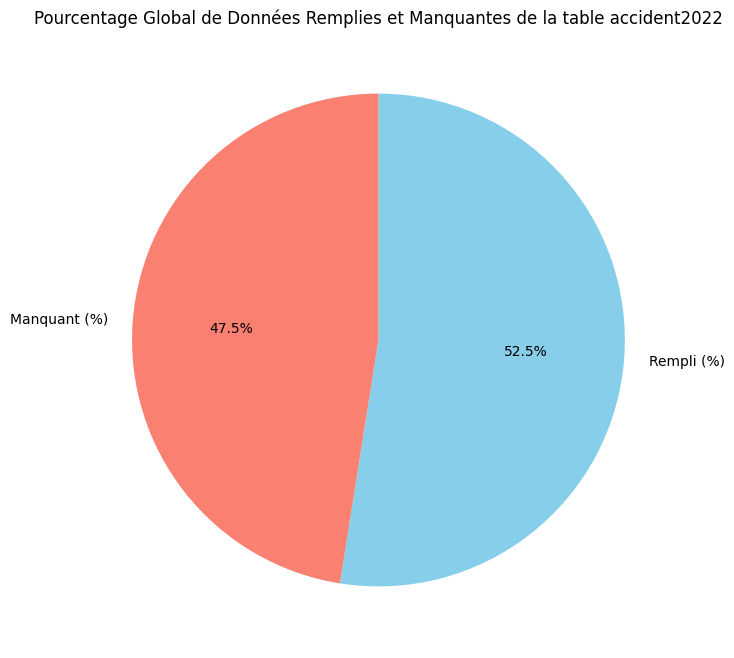

In [ ]:
# Création des données pour le graphique
data = [filled_percentage, missing_percentage]
labels = ['Rempli (%)', 'Manquant (%)']
colors = ['skyblue', 'salmon']

# Création du graphique circulaire
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Pourcentage Global de Données Remplies et Manquantes de la table accident2022')
plt.show()


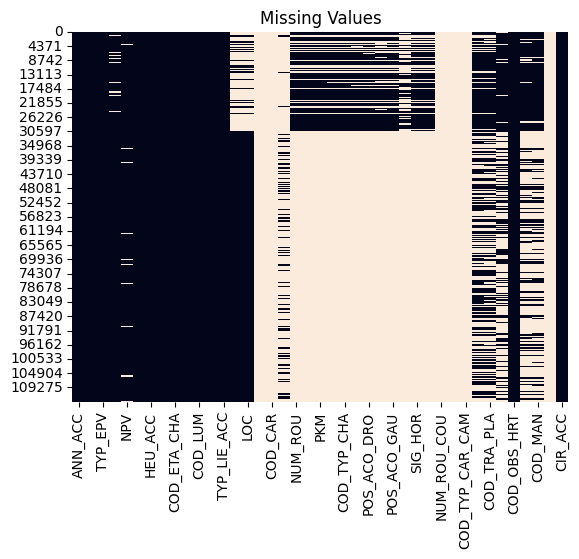

In [ ]:
#on trace un heatmap pour visualiser les données manquantes
sns.heatmap(accident2022.isna() , cbar=False)
plt.title('Missing Values')
plt.show()

In [ ]:
accident2022.isna().sum()/len(accident2022)
#le pourcentage des valeurs manquantes


ANN_ACC            0.000000
NUM_ACC            0.000000
TYP_EPV            0.000000
NUM_EPV            0.030750
NPV                0.025003
DAT_ACC            0.000000
HEU_ACC            0.000000
COD_PRV            0.000000
COD_ETA_CHA        0.000000
COD_ETA_SUR        0.000000
COD_LUM            0.000000
COD_INT            0.000000
TYP_LIE_ACC        0.000000
COD_AGG            0.193531
LOC                0.193839
COD_BOU            0.999912
COD_CAR            0.999982
COD_TYP_CAR_AGG    0.781228
NUM_ROU            0.806469
SUF_NUM_ROU        0.806469
PKM                0.806469
LAR_CHA            0.807683
COD_TYP_CHA        0.809364
LAR_ACO_DRO        0.816202
POS_ACO_DRO        0.814363
LAR_ACO_GAU        0.836084
POS_ACO_GAU        0.820172
COD_TOP            0.873531
SIG_HOR            0.811010
SIG_VER            0.812119
NUM_ROU_COU        0.999824
SUF_NUM_ROU_COU    0.999824
COD_TYP_CAR_CAM    0.999190
COD_PRO_LON        0.406715
COD_TRA_PLA        0.449734
COD_TYP_COL        0

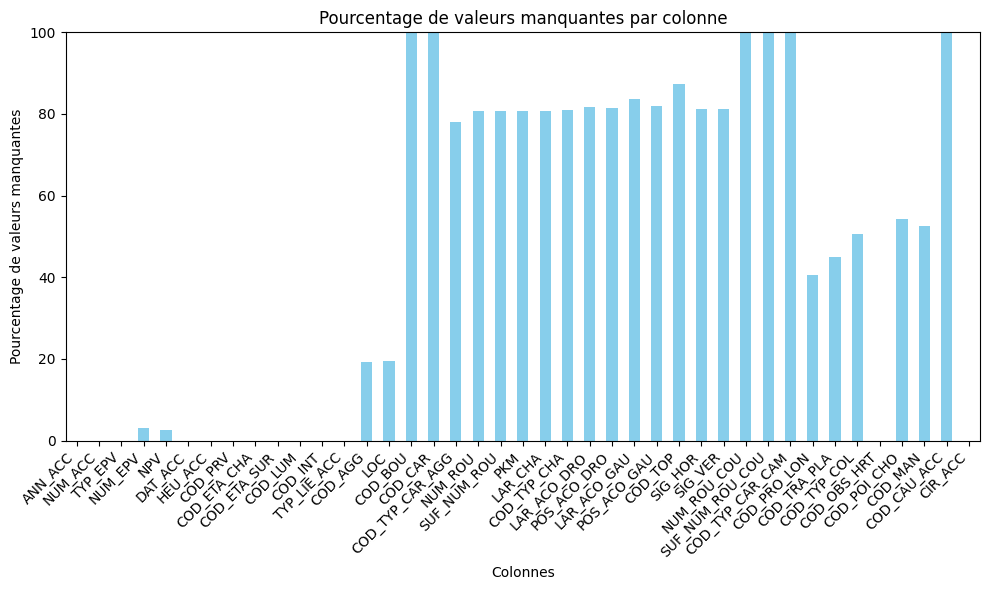

In [ ]:
import matplotlib.pyplot as plt

# Calcul du pourcentage de valeurs manquantes pour chaque colonne
proportion_valeurs_manquantes = accident2022.isna().sum() / len(accident2022) * 100

# Tracé du diagramme à barres
plt.figure(figsize=(10, 6))
proportion_valeurs_manquantes.plot(kind='bar', color='skyblue')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Pourcentage de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # Limiter l'axe y de 0 à 100
plt.tight_layout()
plt.show()


In [ ]:
accident2022 = accident2022.drop(['COD_BOU','COD_CAR','COD_TYP_CAR_AGG','SUF_NUM_ROU',
'NUM_ROU_COU', 'SUF_NUM_ROU_COU' , 'COD_TYP_CAR_CAM','COD_CAU_ACC','LOC','COD_PRV'],axis=1)


**codification de la colone 'LAR_CHA'**





In [ ]:
# Afficher les valeurs uniques de la colonne 'LAR_CHA'
unique_values = accident2022['LAR_CHA'].unique()
print("Valeurs uniques dans la colonne 'LAR_CHA':")
print(unique_values)


Valeurs uniques dans la colonne 'LAR_CHA':
[ 5.  6.  4.  7.  1. nan 15.  3.  8. 10. 11. 12.  2.  9. 16. 18. 17. 19.
 13. 14. 25. 21.  0. 46. 20. 31. 65. 60. 41. 22. 70. 48. 91. 80. 62. 43.
 61. 56. 54. 51. 30. 50. 72. 55. 47. 37. 96. 40. 27. 71. 26. 81. 67. 63.
 90. 28.]


In [ ]:
# Définir la fonction de codification
def code_lar_cha(value):
    if value <= 5:
        return 1
    elif 5 < value <= 10:
        return 2
    elif 10 < value < 25:
        return 3
    elif value >= 25:
        return 4
    else:
        return None  # Au cas où il y a des valeurs manquantes ou inattendues

# Appliquer la fonction de codification à la colonne 'LAR_CHA'
accident2022['LAR_CHA'] = accident2022['LAR_CHA'].apply(code_lar_cha)

# Afficher les premières lignes du DataFrame pour vérifier la codification
print(accident2022.head())

   ANN_ACC  NUM_ACC  TYP_EPV  NUM_EPV    NPV     DAT_ACC  HEU_ACC  \
0     2022        1        1   4107.0  197.0  18/01/2022       19   
1     2022        2        1   4112.0  307.0  15/01/2022       20   
2     2022        3        1   4409.0  317.0  25/01/2022       18   
3     2022        4        1   4306.0  382.0  31/01/2022        8   
4     2022        5        1   4107.0  198.0  18/01/2022       21   

   COD_ETA_CHA  COD_ETA_SUR  COD_LUM  ...  COD_TOP  SIG_HOR  SIG_VER  \
0            1            1        1  ...      NaN      2.0      2.0   
1            1            1        1  ...      NaN      2.0      2.0   
2            1            1        1  ...      NaN      2.0      2.0   
3            1            1        2  ...      NaN      1.0      2.0   
4            1            1        1  ...      NaN      1.0      1.0   

   COD_PRO_LON COD_TRA_PLA  COD_TYP_COL  COD_OBS_HRT  COD_POI_CHO  COD_MAN  \
0          1.0         1.0          3.0           15          6.0      6.0

In [ ]:
# Utiliser rename() pour changer le nom d'une colonne
accident2022.rename(columns={'COD_PRV': 'cod_prv'}, inplace=True)



In [ ]:
print(accident2022.head())

   ANN_ACC  NUM_ACC  TYP_EPV  NUM_EPV    NPV     DAT_ACC  HEU_ACC  \
0     2022        1        1   4107.0  197.0  18/01/2022       19   
1     2022        2        1   4112.0  307.0  15/01/2022       20   
2     2022        3        1   4409.0  317.0  25/01/2022       18   
3     2022        4        1   4306.0  382.0  31/01/2022        8   
4     2022        5        1   4107.0  198.0  18/01/2022       21   

   COD_ETA_CHA  COD_ETA_SUR  COD_LUM  ...  COD_TOP  SIG_HOR  SIG_VER  \
0            1            1        1  ...      NaN      2.0      2.0   
1            1            1        1  ...      NaN      2.0      2.0   
2            1            1        1  ...      NaN      2.0      2.0   
3            1            1        2  ...      NaN      1.0      2.0   
4            1            1        1  ...      NaN      1.0      1.0   

   COD_PRO_LON COD_TRA_PLA  COD_TYP_COL  COD_OBS_HRT  COD_POI_CHO  COD_MAN  \
0          1.0         1.0          3.0           15          6.0      6.0

In [ ]:
import numpy as np
from scipy import stats
 #pour faire des opérations numériques et statistiques


In [ ]:

# Sélectionner uniquement les colonnes numériques
numerical_columns = accident2022.select_dtypes(include=np.number)




In [ ]:
accident2022.isna().sum()
# on vérifie les valeurs manquantes de chaque colonne.
# isna() permet de détecter les valeurs manquantes et sum() compte le nombre de ces valeurs manquantes


ANN_ACC            0
NUM_ACC            0
TYP_EPV            0
NUM_EPV         3494
NPV             2841
DAT_ACC            0
HEU_ACC            0
COD_ETA_CHA        0
COD_ETA_SUR        0
COD_LUM            0
COD_INT            0
TYP_LIE_ACC        0
COD_AGG        21990
NUM_ROU        91635
PKM            91635
LAR_CHA        91773
COD_TYP_CHA    91964
LAR_ACO_DRO    92741
POS_ACO_DRO    92532
LAR_ACO_GAU    95000
POS_ACO_GAU    93192
COD_TOP        99255
SIG_HOR        92151
SIG_VER        92277
COD_PRO_LON    46213
COD_TRA_PLA    51101
COD_TYP_COL    57562
COD_OBS_HRT        0
COD_POI_CHO    61776
COD_MAN        59719
CIR_ACC            0
dtype: int64

In [ ]:
accident2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113625 entries, 0 to 113624
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ANN_ACC      113625 non-null  int64  
 1   NUM_ACC      113625 non-null  int64  
 2   TYP_EPV      113625 non-null  int64  
 3   NUM_EPV      110131 non-null  float64
 4   NPV          110784 non-null  float64
 5   DAT_ACC      113625 non-null  object 
 6   HEU_ACC      113625 non-null  int64  
 7   COD_ETA_CHA  113625 non-null  int64  
 8   COD_ETA_SUR  113625 non-null  int64  
 9   COD_LUM      113625 non-null  int64  
 10  COD_INT      113625 non-null  int64  
 11  TYP_LIE_ACC  113625 non-null  int64  
 12  COD_AGG      91635 non-null   float64
 13  NUM_ROU      21990 non-null   float64
 14  PKM          21990 non-null   object 
 15  LAR_CHA      21852 non-null   float64
 16  COD_TYP_CHA  21661 non-null   float64
 17  LAR_ACO_DRO  20884 non-null   float64
 18  POS_ACO_DRO  21093 non-n

In [ ]:
import pandas as pd

# Supposons que vous ayez déjà chargé votre DataFrame accident2022

# Conversion de la colonne 'PKM' de object à float64
accident2022['PKM'] = pd.to_numeric(accident2022['PKM'], errors='coerce')

# Affichage des types de données après la conversion
print(accident2022.dtypes)


ANN_ACC          int64
NUM_ACC          int64
TYP_EPV          int64
NUM_EPV        float64
NPV            float64
DAT_ACC         object
HEU_ACC          int64
COD_ETA_CHA      int64
COD_ETA_SUR      int64
COD_LUM          int64
COD_INT          int64
TYP_LIE_ACC      int64
COD_AGG        float64
NUM_ROU        float64
PKM            float64
LAR_CHA        float64
COD_TYP_CHA    float64
LAR_ACO_DRO    float64
POS_ACO_DRO    float64
LAR_ACO_GAU    float64
POS_ACO_GAU    float64
COD_TOP        float64
SIG_HOR        float64
SIG_VER        float64
COD_PRO_LON    float64
COD_TRA_PLA    float64
COD_TYP_COL    float64
COD_OBS_HRT      int64
COD_POI_CHO    float64
COD_MAN        float64
CIR_ACC         object
dtype: object


In [ ]:
#on identifie numerical features de notre data
numerical_features = accident2022.select_dtypes(include = ['int64','float64']).columns.values
numerical_features


array(['ANN_ACC', 'NUM_ACC', 'TYP_EPV', 'NUM_EPV', 'NPV', 'HEU_ACC',
       'COD_ETA_CHA', 'COD_ETA_SUR', 'COD_LUM', 'COD_INT', 'TYP_LIE_ACC',
       'COD_AGG', 'NUM_ROU', 'PKM', 'LAR_CHA', 'COD_TYP_CHA',
       'LAR_ACO_DRO', 'POS_ACO_DRO', 'LAR_ACO_GAU', 'POS_ACO_GAU',
       'COD_TOP', 'SIG_HOR', 'SIG_VER', 'COD_PRO_LON', 'COD_TRA_PLA',
       'COD_TYP_COL', 'COD_OBS_HRT', 'COD_POI_CHO', 'COD_MAN'],
      dtype=object)

**imputing categorical features**

In [ ]:
#on identifie categorical features
categorical_features = accident2022.select_dtypes(include = [object]).columns.values
categorical_features

array(['DAT_ACC', 'CIR_ACC'], dtype=object)

In [ ]:
accident2022[categorical_features].head()

,DAT_ACC,CIR_ACC
0,18/01/2022,9/12
1,15/01/2022,9/4
2,25/01/2022,21/5/14
3,31/01/2022,9/4
4,18/01/2022,21/5


In [ ]:
from sklearn.impute import SimpleImputer

# Créer un objet SimpleImputer pour imputer les valeurs manquantes dans les caractéristiques catégoriques
cat_imputer = SimpleImputer(strategy='most_frequent')

# Adapter le SimpleImputer aux données catégoriques(l'objet cat_imputer apprendra à partir des données pour savoir quelles sont les valeurs les plus fréquentes dans chaque colonne catégorique.)
cat_imputer.fit(accident2022[categorical_features])


SimpleImputer(strategy='most_frequent')

In [ ]:
accident2022[categorical_features] = cat_imputer.transform(accident2022[categorical_features])

In [ ]:
accident2022[categorical_features].isnull().sum()

DAT_ACC    0
CIR_ACC    0
dtype: int64

**imputing numerical features**



In [ ]:
from sklearn.impute import KNNImputer
cat_imput = KNNImputer

In [ ]:
accident2022[numerical_features].head()

,ANN_ACC,NUM_ACC,TYP_EPV,NUM_EPV,NPV,HEU_ACC,COD_ETA_CHA,COD_ETA_SUR,COD_LUM,COD_INT,...,POS_ACO_GAU,COD_TOP,SIG_HOR,SIG_VER,COD_PRO_LON,COD_TRA_PLA,COD_TYP_COL,COD_OBS_HRT,COD_POI_CHO,COD_MAN
0,2022,1,1,4107.0,197.0,19,1,1,1,1,...,1.0,NaN,2.0,2.0,1.0,1.0,3.0,15,6.0,6.0
1,2022,2,1,4112.0,307.0,20,1,1,1,1,...,NaN,NaN,2.0,2.0,1.0,2.0,7.0,15,9.0,6.0
2,2022,3,1,4409.0,317.0,18,1,1,1,1,...,1.0,NaN,2.0,2.0,2.0,1.0,8.0,14,NaN,16.0
3,2022,4,1,4306.0,382.0,8,1,1,2,1,...,1.0,NaN,1.0,2.0,2.0,3.0,1.0,15,1.0,4.0
4,2022,5,1,4107.0,198.0,21,1,1,1,1,...,1.0,NaN,1.0,1.0,1.0,2.0,8.0,14,1.0,16.0


In [ ]:
from sklearn.impute import KNNImputer


# on inialise le KNNImputer
cat_imput = KNNImputer()

# Fit the imputer à notre data
cat_imput.fit(accident2022[numerical_features])



KNNImputer()

In [ ]:

# Adapter le KNNImputer aux données numériques
cat_imputer.fit(accident2022[numerical_features])


SimpleImputer(strategy='most_frequent')

In [ ]:
# Utiliser cat_imputer pour imputer les valeurs manquantes dans les caractéristiques numériques de accident2022
accident2022[numerical_features] = cat_imputer.transform(accident2022[numerical_features])


In [ ]:
accident2022[numerical_features] = cat_imput.transform(accident2022[numerical_features])

In [ ]:
accident2022.isnull().sum()

ANN_ACC        0
NUM_ACC        0
TYP_EPV        0
NUM_EPV        0
NPV            0
DAT_ACC        0
HEU_ACC        0
COD_ETA_CHA    0
COD_ETA_SUR    0
COD_LUM        0
COD_INT        0
TYP_LIE_ACC    0
COD_AGG        0
NUM_ROU        0
PKM            0
LAR_CHA        0
COD_TYP_CHA    0
LAR_ACO_DRO    0
POS_ACO_DRO    0
LAR_ACO_GAU    0
POS_ACO_GAU    0
COD_TOP        0
SIG_HOR        0
SIG_VER        0
COD_PRO_LON    0
COD_TRA_PLA    0
COD_TYP_COL    0
COD_OBS_HRT    0
COD_POI_CHO    0
COD_MAN        0
CIR_ACC        0
dtype: int64

In [ ]:
print(accident2022.head())

   ANN_ACC  NUM_ACC  TYP_EPV  NUM_EPV    NPV     DAT_ACC  HEU_ACC  \
0   2022.0      1.0      1.0   4107.0  197.0  18/01/2022     19.0   
1   2022.0      2.0      1.0   4112.0  307.0  15/01/2022     20.0   
2   2022.0      3.0      1.0   4409.0  317.0  25/01/2022     18.0   
3   2022.0      4.0      1.0   4306.0  382.0  31/01/2022      8.0   
4   2022.0      5.0      1.0   4107.0  198.0  18/01/2022     21.0   

   COD_ETA_CHA  COD_ETA_SUR  COD_LUM  ...  COD_TOP  SIG_HOR  SIG_VER  \
0          1.0          1.0      1.0  ...      1.0      2.0      2.0   
1          1.0          1.0      1.0  ...      1.0      2.0      2.0   
2          1.0          1.0      1.0  ...      1.0      2.0      2.0   
3          1.0          1.0      2.0  ...      1.0      1.0      2.0   
4          1.0          1.0      1.0  ...      1.0      1.0      1.0   

   COD_PRO_LON  COD_TRA_PLA  COD_TYP_COL  COD_OBS_HRT  COD_POI_CHO  COD_MAN  \
0          1.0          1.0          3.0         15.0          6.0      6

In [ ]:
accident2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113625 entries, 0 to 113624
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ANN_ACC      113625 non-null  float64
 1   NUM_ACC      113625 non-null  float64
 2   TYP_EPV      113625 non-null  float64
 3   NUM_EPV      113625 non-null  float64
 4   NPV          113625 non-null  float64
 5   DAT_ACC      113625 non-null  object 
 6   HEU_ACC      113625 non-null  float64
 7   COD_ETA_CHA  113625 non-null  float64
 8   COD_ETA_SUR  113625 non-null  float64
 9   COD_LUM      113625 non-null  float64
 10  COD_INT      113625 non-null  float64
 11  TYP_LIE_ACC  113625 non-null  float64
 12  COD_AGG      113625 non-null  float64
 13  NUM_ROU      113625 non-null  float64
 14  PKM          113625 non-null  float64
 15  LAR_CHA      113625 non-null  float64
 16  COD_TYP_CHA  113625 non-null  float64
 17  LAR_ACO_DRO  113625 non-null  float64
 18  POS_ACO_DRO  113625 non-

In [ ]:
accident2022.to_csv('/content/bd acc 2022.csv', index=False)

# - Prétraitement sur la base de données vehicules

In [ ]:
vehicules = pd.read_csv("/content/vehicule4.csv")

In [ ]:
chemin_fichier_csv = "/content/vehicule4.csv"


In [ ]:
vehicules = pd.read_csv(chemin_fichier_csv, delimiter=';')

In [ ]:
# Calcul du nombre total de valeurs dans le DataFrame
total_values = vehicules.size

# Calcul du nombre total de valeurs manquantes
total_missing = vehicules.isna().sum().sum()

# Calcul du pourcentage de valeurs manquantes
missing_percentage = (total_missing / total_values) * 100

# Calcul du pourcentage de valeurs remplies
filled_percentage = 100 - missing_percentage

# Affichage des pourcentages
print(f"Pourcentage de données remplies : {filled_percentage:.2f}%")
print(f"Pourcentage de données manquantes : {missing_percentage:.2f}%")

Pourcentage de données remplies : 79.12%
Pourcentage de données manquantes : 20.88%


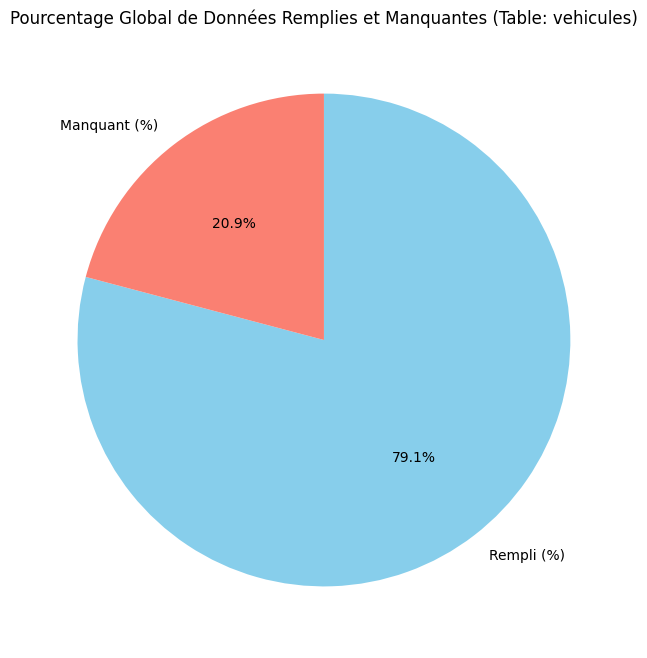

In [ ]:
# Création des données pour le graphique
data = [filled_percentage, missing_percentage]
labels = ['Rempli (%)', 'Manquant (%)']
colors = ['skyblue', 'salmon']

# Création du graphique circulaire
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Pourcentage Global de Données Remplies et Manquantes (Table: vehicules)')
plt.show()


In [ ]:
vehicules.isna().sum()/len(vehicules)
#le pourcentage des valeurs manquantes


ANN_ACC            0.000000
NUM_ACC            0.000000
NUM_ORD_VEH        0.000000
COD_TYP_VEH        0.000000
REM                0.198272
ASS                0.094441
COD_USA_VEH        0.000000
COD_PAY_ORI        0.003310
ANN_MIS_SCE        0.452795
ANN_VIS_TEC        0.690355
MOI_VIS_TEC        0.690401
COD_DEF_MEC        0.000000
AGE_CON            0.056514
SEX_CON            0.041108
COD_NAT_CON        0.000516
COD_PRF_CON        0.003181
CON_RES_MAR        0.062995
COD_CAT_PER        0.002599
ANN_DEL_PER        0.571459
LIE_DEL_PER        0.504246
VAL_PER            0.509737
COD_TRA            0.001325
COD_TUE            0.000000
COD_BLE            0.000000
POR_CAS            0.715701
POR_CNT_SEC        0.664859
COD_FAU_CON        0.000000
COD_FAC_PHY        0.000000
COD_FAU_NON_CON    0.000000
RES_ADM            1.000000
dtype: float64

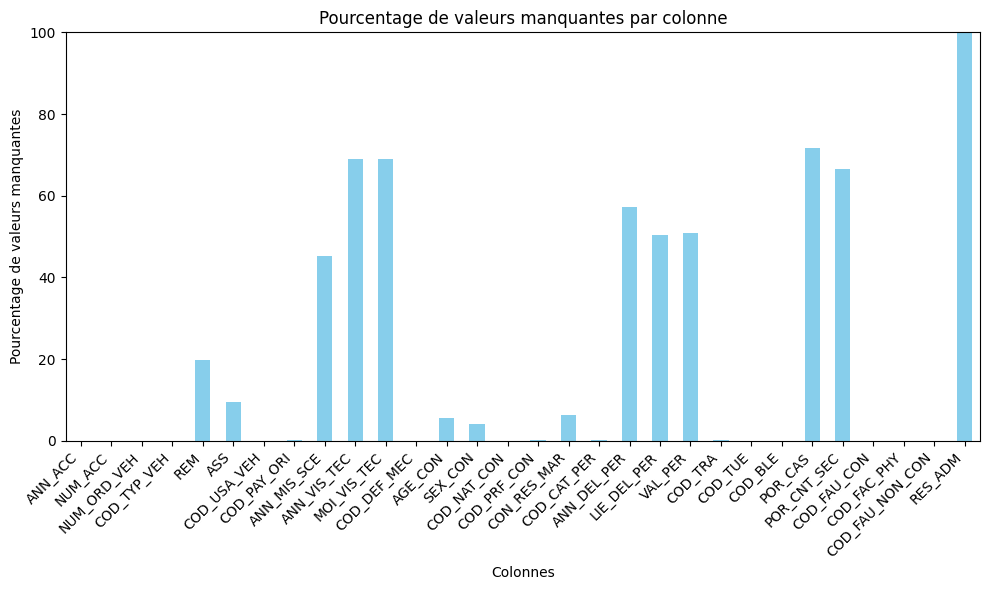

In [ ]:
import matplotlib.pyplot as plt

# Calcul du pourcentage de valeurs manquantes pour chaque colonne
proportion_valeurs_manquantes = vehicules.isna().sum() / len(vehicules) * 100

# Tracé du diagramme à barres
plt.figure(figsize=(10, 6))
proportion_valeurs_manquantes.plot(kind='bar', color='skyblue')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Pourcentage de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # Limiter l'axe y de 0 à 100
plt.tight_layout()
plt.show()


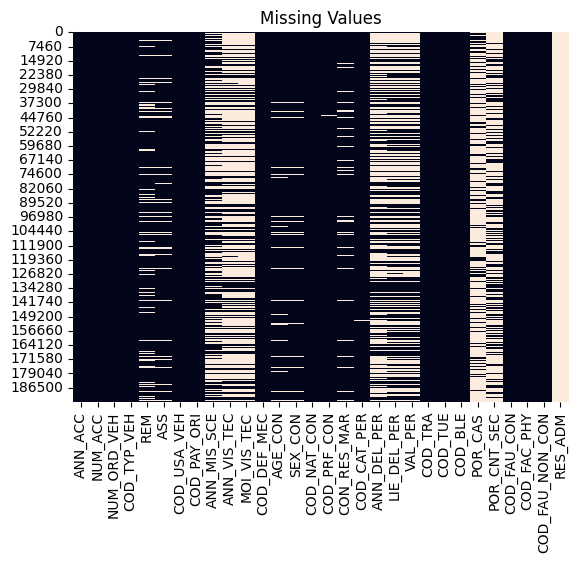

In [ ]:
#on trace un heatmap pour visualiser les données manquantes
sns.heatmap(vehicules.isna() , cbar=False)
plt.title('Missing Values')
plt.show()

In [ ]:
vehicules = vehicules.drop(['ANN_VIS_TEC','MOI_VIS_TEC','COD_NAT_CON','RES_ADM',
'COD_PAY_ORI', 'POR_CAS' , 'POR_CNT_SEC','COD_FAU_CON','COD_PAY_ORI' , 'COD_FAU_CON','COD_USA_VEH','COD_PRF_CON',],axis=1)


In [ ]:
print(vehicules.head())

   ANN_ACC  NUM_ACC  NUM_ORD_VEH  COD_TYP_VEH  REM  ASS  ANN_MIS_SCE  \
0     2022     8580            2            1  2.0  1.0       2014.0   
1     2022     8581            1            3  2.0  1.0       2014.0   
2     2022     8581            2            1  2.0  1.0       2019.0   
3     2022     8581            3            1  2.0  2.0       2016.0   
4     2022     8582            1            3  2.0  1.0       2021.0   

   COD_DEF_MEC  AGE_CON  SEX_CON  CON_RES_MAR  COD_CAT_PER  ANN_DEL_PER  \
0            9     47.0      1.0          1.0          0.0          NaN   
1            9     36.0      1.0          1.0          1.0       2020.0   
2            9     17.0      1.0          1.0          0.0          NaN   
3            9     22.0      1.0          1.0          0.0          NaN   
4            9     37.0      1.0          2.0          1.0       2020.0   

   LIE_DEL_PER  VAL_PER  COD_TRA  COD_TUE  COD_BLE  COD_FAC_PHY  \
0          NaN      NaN      0.0        1        

In [ ]:
vehicules.isna().sum()


ANN_ACC                 0
NUM_ACC                 0
NUM_ORD_VEH             0
COD_TYP_VEH             0
REM                 38455
ASS                 18317
ANN_MIS_SCE         87820
COD_DEF_MEC             0
AGE_CON             10961
SEX_CON              7973
CON_RES_MAR         12218
COD_CAT_PER           504
ANN_DEL_PER        110835
LIE_DEL_PER         97799
VAL_PER             98864
COD_TRA               257
COD_TUE                 0
COD_BLE                 0
COD_FAC_PHY             0
COD_FAU_NON_CON         0
dtype: int64

In [ ]:
len(vehicules)

193951

In [ ]:
vehicules.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193951 entries, 0 to 193950
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ANN_ACC          193951 non-null  int64  
 1   NUM_ACC          193951 non-null  int64  
 2   NUM_ORD_VEH      193951 non-null  int64  
 3   COD_TYP_VEH      193951 non-null  int64  
 4   REM              155496 non-null  float64
 5   ASS              175634 non-null  float64
 6   ANN_MIS_SCE      106131 non-null  float64
 7   COD_DEF_MEC      193951 non-null  int64  
 8   AGE_CON          182990 non-null  float64
 9   SEX_CON          185978 non-null  float64
 10  CON_RES_MAR      181733 non-null  float64
 11  COD_CAT_PER      193447 non-null  float64
 12  ANN_DEL_PER      83116 non-null   float64
 13  LIE_DEL_PER      96152 non-null   float64
 14  VAL_PER          95087 non-null   float64
 15  COD_TRA          193694 non-null  float64
 16  COD_TUE          193951 non-null  int6

In [ ]:
# Calcul du nombre total de valeurs manquantes pour chaque colonne
vehicules.isna().sum()



ANN_ACC                 0
NUM_ACC                 0
NUM_ORD_VEH             0
COD_TYP_VEH             0
REM                 38455
ASS                 18317
ANN_MIS_SCE         87820
COD_DEF_MEC             0
AGE_CON             10961
SEX_CON              7973
CON_RES_MAR         12218
COD_CAT_PER           504
ANN_DEL_PER        110835
LIE_DEL_PER         97799
VAL_PER             98864
COD_TRA               257
COD_TUE                 0
COD_BLE                 0
COD_FAC_PHY             0
COD_FAU_NON_CON         0
dtype: int64

In [ ]:
#on identifie numerical features de notre data
numerical_features = vehicules.select_dtypes(include = ['int64','float64']).columns.values
numerical_features


array(['ANN_ACC', 'NUM_ACC', 'NUM_ORD_VEH', 'COD_TYP_VEH', 'REM', 'ASS',
       'ANN_MIS_SCE', 'COD_DEF_MEC', 'AGE_CON', 'SEX_CON', 'CON_RES_MAR',
       'COD_CAT_PER', 'ANN_DEL_PER', 'LIE_DEL_PER', 'VAL_PER', 'COD_TRA',
       'COD_TUE', 'COD_BLE', 'COD_FAC_PHY', 'COD_FAU_NON_CON'],
      dtype=object)

In [ ]:
from sklearn.impute import KNNImputer


# on inialise le KNNImputer
cat_imput = KNNImputer()

# Fit the imputer à notre data
cat_imput.fit(vehicules[numerical_features])

# Adapter le KNNImputer aux données numériques
cat_imputer.fit(vehicules[numerical_features])

# Utiliser cat_imputer pour imputer les valeurs manquantes dans les caractéristiques numériques de vehicules
vehicules[numerical_features] = cat_imputer.transform(vehicules[numerical_features])

vehicules[numerical_features] = cat_imput.transform(vehicules[numerical_features])

In [ ]:
vehicules[numerical_features].head()

,ANN_ACC,NUM_ACC,NUM_ORD_VEH,COD_TYP_VEH,REM,ASS,ANN_MIS_SCE,COD_DEF_MEC,AGE_CON,SEX_CON,CON_RES_MAR,COD_CAT_PER,ANN_DEL_PER,LIE_DEL_PER,VAL_PER,COD_TRA,COD_TUE,COD_BLE,COD_FAC_PHY,COD_FAU_NON_CON
0,2022.0,8580.0,2.0,1.0,2.0,1.0,2014.0,9.0,47.0,1.0,1.0,0.0,2010.0,1.0,1.0,0.0,1.0,0.0,9.0,9.0
1,2022.0,8581.0,1.0,3.0,2.0,1.0,2014.0,9.0,36.0,1.0,1.0,1.0,2020.0,1.0,2.0,0.0,0.0,0.0,9.0,9.0
2,2022.0,8581.0,2.0,1.0,2.0,1.0,2019.0,9.0,17.0,1.0,1.0,0.0,2010.0,1.0,1.0,0.0,1.0,0.0,1.0,9.0
3,2022.0,8581.0,3.0,1.0,2.0,2.0,2016.0,9.0,22.0,1.0,1.0,0.0,2010.0,1.0,1.0,0.0,0.0,0.0,9.0,9.0
4,2022.0,8582.0,1.0,3.0,2.0,1.0,2021.0,9.0,37.0,1.0,2.0,1.0,2020.0,2.0,2.0,0.0,0.0,0.0,9.0,9.0


In [ ]:
vehicules.head()

,ANN_ACC,NUM_ACC,NUM_ORD_VEH,COD_TYP_VEH,REM,ASS,ANN_MIS_SCE,COD_DEF_MEC,AGE_CON,SEX_CON,CON_RES_MAR,COD_CAT_PER,ANN_DEL_PER,LIE_DEL_PER,VAL_PER,COD_TRA,COD_TUE,COD_BLE,COD_FAC_PHY,COD_FAU_NON_CON
0,2022.0,8580.0,2.0,1.0,2.0,1.0,2014.0,9.0,47.0,1.0,1.0,0.0,2010.0,1.0,1.0,0.0,1.0,0.0,9.0,9.0
1,2022.0,8581.0,1.0,3.0,2.0,1.0,2014.0,9.0,36.0,1.0,1.0,1.0,2020.0,1.0,2.0,0.0,0.0,0.0,9.0,9.0
2,2022.0,8581.0,2.0,1.0,2.0,1.0,2019.0,9.0,17.0,1.0,1.0,0.0,2010.0,1.0,1.0,0.0,1.0,0.0,1.0,9.0
3,2022.0,8581.0,3.0,1.0,2.0,2.0,2016.0,9.0,22.0,1.0,1.0,0.0,2010.0,1.0,1.0,0.0,0.0,0.0,9.0,9.0
4,2022.0,8582.0,1.0,3.0,2.0,1.0,2021.0,9.0,37.0,1.0,2.0,1.0,2020.0,2.0,2.0,0.0,0.0,0.0,9.0,9.0


In [ ]:
vehicules.isnull().sum()

ANN_ACC            0
NUM_ACC            0
NUM_ORD_VEH        0
COD_TYP_VEH        0
REM                0
ASS                0
ANN_MIS_SCE        0
COD_DEF_MEC        0
AGE_CON            0
SEX_CON            0
CON_RES_MAR        0
COD_CAT_PER        0
ANN_DEL_PER        0
LIE_DEL_PER        0
VAL_PER            0
COD_TRA            0
COD_TUE            0
COD_BLE            0
COD_FAC_PHY        0
COD_FAU_NON_CON    0
dtype: int64

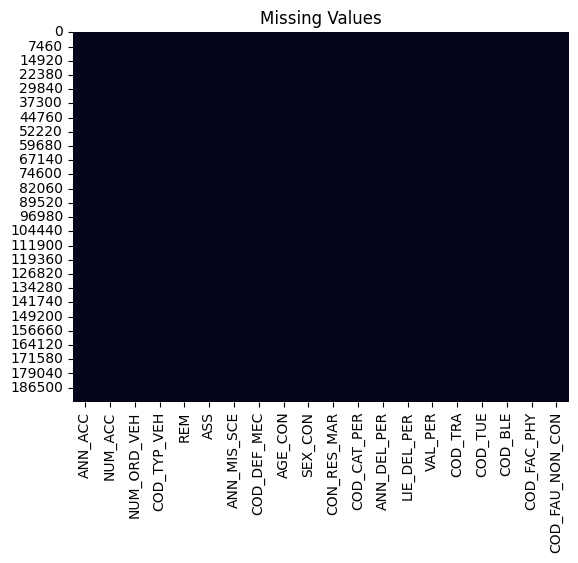

In [ ]:
#on trace un heatmap pour visualiser les données manquantes
sns.heatmap(vehicules.isna() , cbar=False)
plt.title('Missing Values')
plt.show()

In [ ]:
print(vehicules.head())

   ANN_ACC  NUM_ACC  NUM_ORD_VEH  COD_TYP_VEH  REM  ASS  ANN_MIS_SCE  \
0   2022.0   8580.0          2.0          1.0  2.0  1.0       2014.0   
1   2022.0   8581.0          1.0          3.0  2.0  1.0       2014.0   
2   2022.0   8581.0          2.0          1.0  2.0  1.0       2019.0   
3   2022.0   8581.0          3.0          1.0  2.0  2.0       2016.0   
4   2022.0   8582.0          1.0          3.0  2.0  1.0       2021.0   

   COD_DEF_MEC  AGE_CON  SEX_CON  CON_RES_MAR  COD_CAT_PER  ANN_DEL_PER  \
0          9.0     47.0      1.0          1.0          0.0       2010.0   
1          9.0     36.0      1.0          1.0          1.0       2020.0   
2          9.0     17.0      1.0          1.0          0.0       2010.0   
3          9.0     22.0      1.0          1.0          0.0       2010.0   
4          9.0     37.0      1.0          2.0          1.0       2020.0   

   LIE_DEL_PER  VAL_PER  COD_TRA  COD_TUE  COD_BLE  COD_FAC_PHY  \
0          1.0      1.0      0.0      1.0      0.



```
# Ce texte est au format code
```

# - Prétraitement sur la base de données passagers

In [ ]:
passagers = pd.read_csv("/content/vehicule4.csv")

In [ ]:
chemin_fichier_csv = "/content/passagers.csv"


In [ ]:
passagers = pd.read_csv(chemin_fichier_csv, delimiter=';')

In [ ]:
# Calcul du nombre total de valeurs dans le DataFrame
total_values = passagers.size

# Calcul du nombre total de valeurs manquantes
total_missing = passagers.isna().sum().sum()

# Calcul du pourcentage de valeurs manquantes
missing_percentage = (total_missing / total_values) * 100

# Calcul du pourcentage de valeurs remplies
filled_percentage = 100 - missing_percentage

# Affichage des pourcentages
print(f"Pourcentage de données remplies : {filled_percentage:.2f}%")
print(f"Pourcentage de données manquantes : {missing_percentage:.2f}%")

Pourcentage de données remplies : 98.93%
Pourcentage de données manquantes : 1.07%


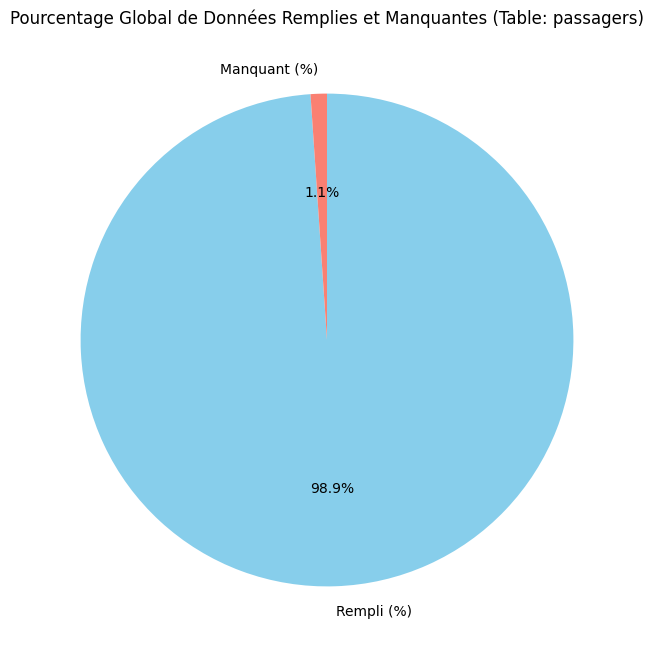

In [ ]:
# Création des données pour le graphique
data = [filled_percentage, missing_percentage]
labels = ['Rempli (%)', 'Manquant (%)']
colors = ['skyblue', 'salmon']

# Création du graphique circulaire
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Pourcentage Global de Données Remplies et Manquantes (Table: passagers)')
plt.show()


In [ ]:
 passagers.isna().sum()/len(passagers)

ANN_ACC            0.000000
NUM_ACC            0.000000
NUM_ORD_PAS_VIC    0.000000
NUM_ORD_VEH        0.000000
COD_PLA_VEH        0.055843
AGE_PASSA          0.036712
SEX_PASSA          0.010681
COD_PRF            0.003553
COD_TUE            0.000000
COD_BLE            0.000000
dtype: float64

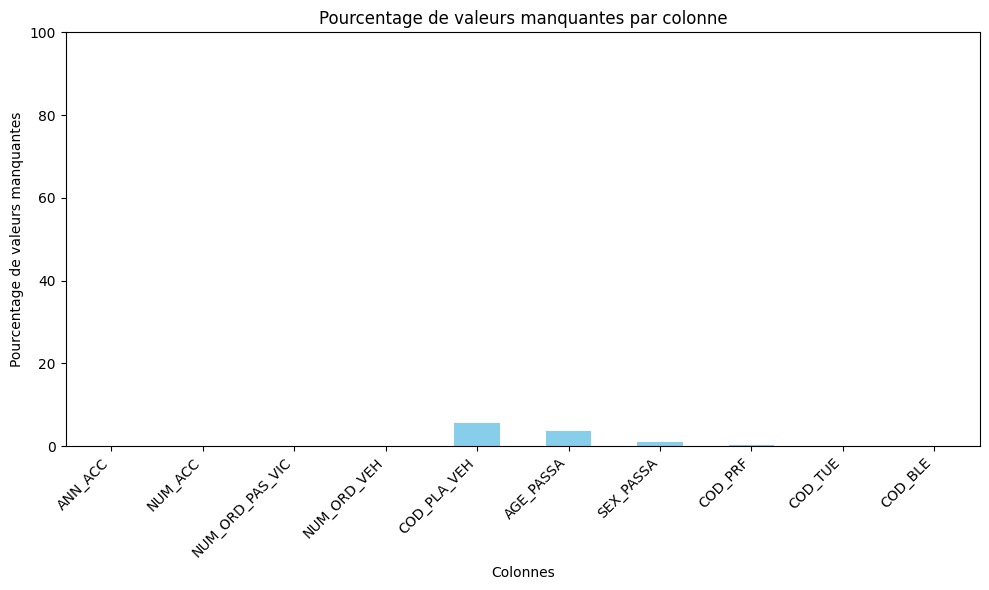

In [ ]:
import matplotlib.pyplot as plt

# Calcul du pourcentage de valeurs manquantes pour chaque colonne
proportion_valeurs_manquantes = passagers.isna().sum() / len(passagers) * 100

# Tracé du diagramme à barres
plt.figure(figsize=(10, 6))
proportion_valeurs_manquantes.plot(kind='bar', color='skyblue')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Pourcentage de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # Limiter l'axe y de 0 à 100
plt.tight_layout()
plt.show()


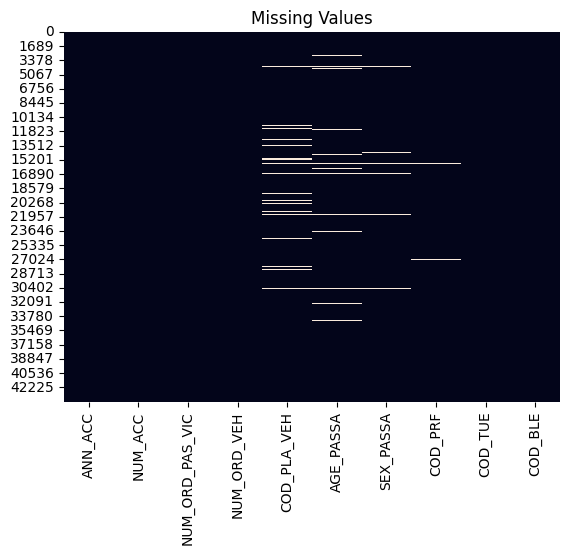

In [ ]:
#on trace un heatmap pour visualiser les données manquantes

sns.heatmap(passagers.isna() , cbar=False)

plt.title('Missing Values')

plt.show()

In [ ]:
passagers = passagers.drop(['NUM_ORD_VEH','COD_PRF'],axis=1)


In [ ]:
passagers.isnull().sum()

ANN_ACC               0
NUM_ACC               0
NUM_ORD_PAS_VIC       0
COD_PLA_VEH        2452
AGE_PASSA          1612
SEX_PASSA           469
COD_TUE               0
COD_BLE               0
dtype: int64

In [ ]:
passagers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43909 entries, 0 to 43908
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ANN_ACC          43909 non-null  int64  
 1   NUM_ACC          43909 non-null  int64  
 2   NUM_ORD_PAS_VIC  43909 non-null  int64  
 3   COD_PLA_VEH      41457 non-null  float64
 4   AGE_PASSA        42297 non-null  float64
 5   SEX_PASSA        43440 non-null  float64
 6   COD_TUE          43909 non-null  int64  
 7   COD_BLE          43909 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 2.7 MB


In [ ]:
#on identifie numerical features de notre data
numerical_features = passagers.select_dtypes(include = ['int64','float64']).columns.values

numerical_features

array(['ANN_ACC', 'NUM_ACC', 'NUM_ORD_PAS_VIC', 'COD_PLA_VEH',
       'AGE_PASSA', 'SEX_PASSA', 'COD_TUE', 'COD_BLE'], dtype=object)

In [ ]:
 passagers[numerical_features].head()

,ANN_ACC,NUM_ACC,NUM_ORD_PAS_VIC,COD_PLA_VEH,AGE_PASSA,SEX_PASSA,COD_TUE,COD_BLE
0,2022,13891,4,9.0,41.0,1.0,0,2
1,2022,13892,1,7.0,18.0,1.0,0,2
2,2022,13893,1,7.0,75.0,2.0,0,2
3,2022,13893,2,6.0,19.0,2.0,0,2
4,2022,13895,1,2.0,22.0,1.0,0,2


In [ ]:
cat_imput.fit(passagers[numerical_features])

KNNImputer()

In [ ]:
passagers[numerical_features] = cat_imput.transform(passagers[numerical_features])


In [ ]:
passagers.isnull().sum()

ANN_ACC            0
NUM_ACC            0
NUM_ORD_PAS_VIC    0
COD_PLA_VEH        0
AGE_PASSA          0
SEX_PASSA          0
COD_TUE            0
COD_BLE            0
dtype: int64

# Prétraitement sur la base de données piétons

In [ ]:
pietons = pd.read_csv("/content/pietons12.csv")

In [ ]:
chemin_fichier_csv = "/content/pietons12.csv"

In [ ]:
pietons = pd.read_csv(chemin_fichier_csv, delimiter=';')

In [ ]:
# Calcul du nombre total de valeurs dans le DataFrame
total_values = pietons.size

# Calcul du nombre total de valeurs manquantes
total_missing = pietons.isna().sum().sum()

# Calcul du pourcentage de valeurs manquantes
missing_percentage = (total_missing / total_values) * 100

# Calcul du pourcentage de valeurs remplies
filled_percentage = 100 - missing_percentage

# Affichage des pourcentages
print(f"Pourcentage de données remplies : {filled_percentage:.2f}%")
print(f"Pourcentage de données manquantes : {missing_percentage:.2f}%")

Pourcentage de données remplies : 99.69%
Pourcentage de données manquantes : 0.31%


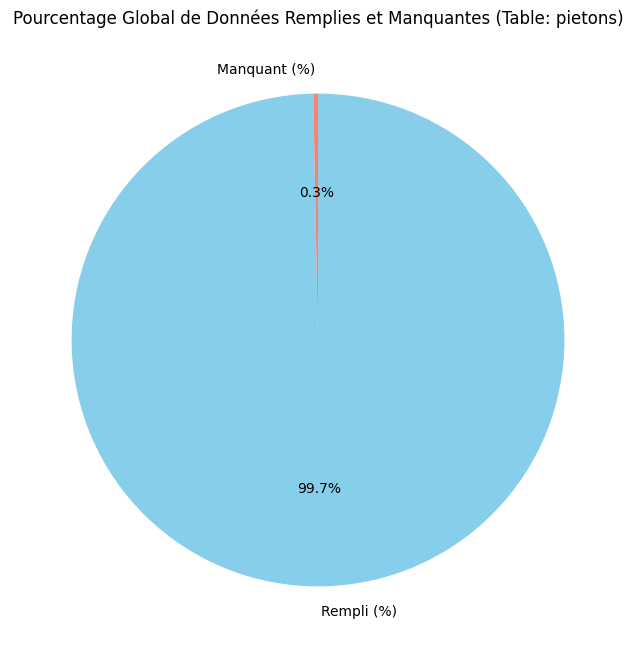

In [ ]:
# Création des données pour le graphique
data = [filled_percentage, missing_percentage]
labels = ['Rempli (%)', 'Manquant (%)']
colors = ['skyblue', 'salmon']

# Création du graphique circulaire
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Pourcentage Global de Données Remplies et Manquantes (Table: pietons)')
plt.show()


In [ ]:
pietons = pietons.drop(['COD_PRF'],axis=1)

In [ ]:
pietons.isna().sum()
#on vérifie les valeurs manquantes de chaque colonne.

#isna() permet de détecter les valeurs manquantes et sum() compte le nombre de ces valeurs manquantes


ANN_ACC              0
NUM_ACC              0
NUM_ORD_PIE_VIC      0
AGE_PIE            707
SEX_PIE             71
COD_TUE              0
COD_BLE              0
COD_FAC_PHY          0
COD_FAU_PIE          0
dtype: int64

In [ ]:
len(pietons)

28872

In [ ]:
pietons.isna().sum()/len(pietons)

ANN_ACC            0.000000
NUM_ACC            0.000000
NUM_ORD_PIE_VIC    0.000000
AGE_PIE            0.024487
SEX_PIE            0.002459
COD_TUE            0.000000
COD_BLE            0.000000
COD_FAC_PHY        0.000000
COD_FAU_PIE        0.000000
dtype: float64

In [ ]:
pietons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28872 entries, 0 to 28871
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ANN_ACC          28872 non-null  int64  
 1   NUM_ACC          28872 non-null  int64  
 2   NUM_ORD_PIE_VIC  28872 non-null  int64  
 3   AGE_PIE          28165 non-null  float64
 4   SEX_PIE          28801 non-null  float64
 5   COD_TUE          28872 non-null  int64  
 6   COD_BLE          28872 non-null  int64  
 7   COD_FAC_PHY      28872 non-null  int64  
 8   COD_FAU_PIE      28872 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 2.0 MB


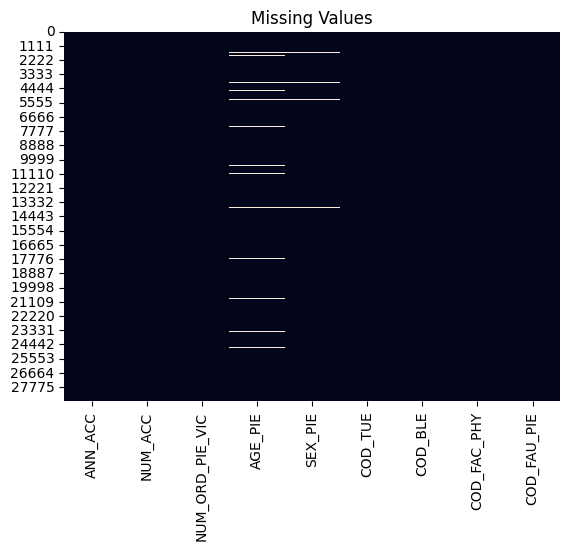

In [ ]:
#on trace un heatmap pour visualiser les données manquantes

sns.heatmap(pietons.isna() , cbar=False)

plt.title('Missing Values')

plt.show()


In [ ]:
 #on identifie numerical features de notre data
numerical_features = pietons.select_dtypes(include = ['int64','float64']).columns.values
numerical_features

array(['ANN_ACC', 'NUM_ACC', 'NUM_ORD_PIE_VIC', 'AGE_PIE', 'SEX_PIE',
       'COD_TUE', 'COD_BLE', 'COD_FAC_PHY', 'COD_FAU_PIE'], dtype=object)

In [ ]:
#affichage des données numériques
pietons[numerical_features].head()


,ANN_ACC,NUM_ACC,NUM_ORD_PIE_VIC,AGE_PIE,SEX_PIE,COD_TUE,COD_BLE,COD_FAC_PHY,COD_FAU_PIE
0,2022,340,1,47.0,1.0,0,2,9,9
1,2022,346,1,7.0,1.0,0,2,9,1
2,2022,347,1,14.0,2.0,0,2,9,4
3,2022,348,1,25.0,1.0,0,2,9,2
4,2022,348,2,18.0,1.0,0,2,9,2


In [ ]:
cat_imput.fit(pietons[numerical_features])

KNNImputer()

In [ ]:
pietons[numerical_features] = cat_imput.transform(pietons[numerical_features])

In [ ]:
pietons.isnull().sum()

ANN_ACC            0
NUM_ACC            0
NUM_ORD_PIE_VIC    0
AGE_PIE            0
SEX_PIE            0
COD_TUE            0
COD_BLE            0
COD_FAC_PHY        0
COD_FAU_PIE        0
dtype: int64

## prétraitement ISR ( indice sécurité routière )

In [ ]:
import pandas as pd

# Charger les tables ISR
ISR = pd.read_csv("/content/ISR.csv",sep=";", encoding="ISO-8859-1") # Assurez-vous d'adapter le nom du fichier au vôtre




In [ ]:
ISR.head()

,ROUTE,PKD,PKF,CLASSE_ISR,NB_ACC,NB_TUE,NB_BLG,NB_BLL,PROVINCE,REGION,Victimes,cod_prv
0,R315,5,9,1,382,15.0,15.0,567.0,Casablanca,Casablanca-Settat,597,NaN
1,P2017,4,8,1,299,8.0,58.0,378.0,Marrakech,Marrakech-Safi,444,NaN
2,N1,289,293,1,291,7.0,25.0,427.0,Skhirate-Témara,Rabat-Salé-Kénitra,459,NaN
3,N7,132,136,1,277,21.0,55.0,314.0,Marrakech,Marrakech-Safi,390,NaN
4,P2017,8,12,1,268,11.0,41.0,365.0,Marrakech,Marrakech-Safi,417,NaN


In [ ]:
ISR = ISR.drop(['cod_prv'],axis=1)

In [ ]:
# Renommer la colonne 'ROUTE' en 'NUM_ROU'
ISR.rename(columns={'ROUTE': 'NUM_ROU'}, inplace=True)

In [ ]:
# Calcul du nombre total de valeurs dans le DataFrame
total_values = ISR.size

# Calcul du nombre total de valeurs manquantes
total_missing = ISR.isna().sum().sum()

# Calcul du pourcentage de valeurs manquantes
missing_percentage = (total_missing / total_values) * 100

# Calcul du pourcentage de valeurs remplies
filled_percentage = 100 - missing_percentage

# Affichage des pourcentages
print(f"Pourcentage de données remplies : {filled_percentage:.2f}%")
print(f"Pourcentage de données manquantes : {missing_percentage:.2f}%")

Pourcentage de données remplies : 90.59%
Pourcentage de données manquantes : 9.41%


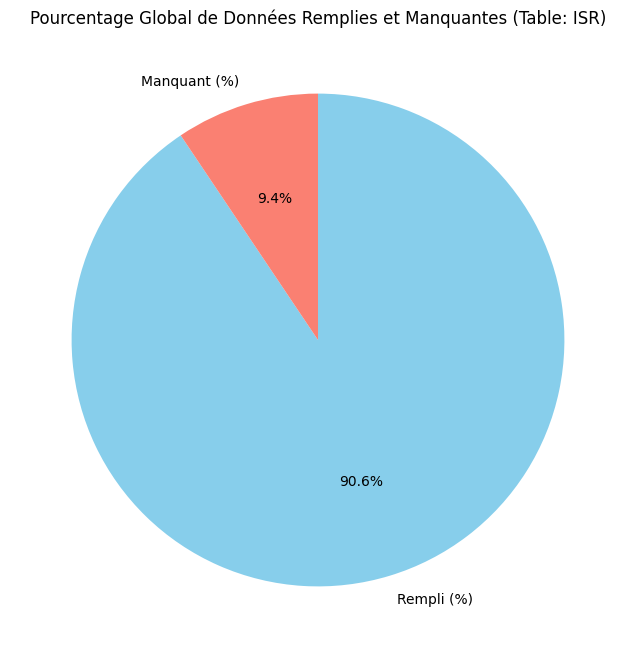

In [ ]:
# Création des données pour le graphique
data = [filled_percentage, missing_percentage]
labels = ['Rempli (%)', 'Manquant (%)']
colors = ['skyblue', 'salmon']

# Création du graphique circulaire
plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Pourcentage Global de Données Remplies et Manquantes (Table: ISR)')
plt.show()


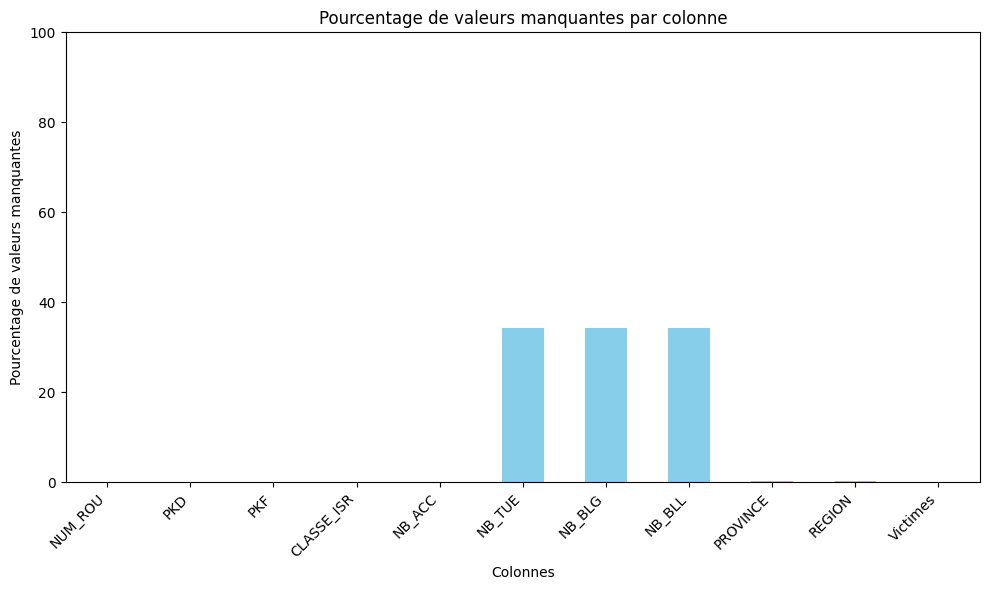

In [ ]:
import matplotlib.pyplot as plt

# Calcul du pourcentage de valeurs manquantes pour chaque colonne
proportion_valeurs_manquantes = ISR.isna().sum() / len(ISR) * 100

# Tracé du diagramme à barres
plt.figure(figsize=(10, 6))
proportion_valeurs_manquantes.plot(kind='bar', color='skyblue')
plt.title('Pourcentage de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Pourcentage de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # Limiter l'axe y de 0 à 100
plt.tight_layout()
plt.show()


In [ ]:

import re

# Définir une fonction pour extraire les parties numériques et les convertir en float
def extraire_nombre(chaine):
    # Utiliser une expression régulière pour extraire les parties numériques
    chiffres = re.findall(r'\d+\.\d+|\d+', chaine)
    # Si des chiffres sont trouvés, retourner le premier élément trouvé
    if chiffres:
        return float(chiffres[0])
    else:
        return None  # Retourner None si aucun chiffre n'est trouvé

# Appliquer la fonction à la colonne 'route' de votre DataFrame
ISR['NUM_ROU'] = ISR['NUM_ROU'].apply(extraire_nombre)


# Afficher les premières lignes pour vérifier les modifications
print(ISR.head(20))

# Sauvegarder le résultat dans un fichier CSV si nécessaire
ISR.to_csv('/content/ISR_NEW.csv', index=False)





    NUM_ROU  PKD  PKF  CLASSE_ISR  NB_ACC  NB_TUE  NB_BLG  NB_BLL  \
0     315.0    5    9           1     382    15.0    15.0   567.0   
1    2017.0    4    8           1     299     8.0    58.0   378.0   
2       1.0  289  293           1     291     7.0    25.0   427.0   
3       7.0  132  136           1     277    21.0    55.0   314.0   
4    2017.0    8   12           1     268    11.0    41.0   365.0   
5     320.0   14   18           1     267    17.0    30.0   366.0   
6       8.0  223  227           1     265    12.0    49.0   301.0   
7       1.0  332  336           1     247    13.0    25.0   338.0   
8       9.0    6   10           1     232     9.0    10.0   317.0   
9       9.0   35   38           1     214     5.0    17.0   305.0   
10    301.0    4    8           1     213    10.0    24.0   361.0   
11      9.0   31   35           1     210     7.0    17.0   290.0   
12    320.0   27   31           1     203     3.0    10.0   284.0   
13   1014.0   10   14           1 

In [ ]:
import pandas as pd

# Charger les tables en spécifiant le délimiteur correct et gérer les erreurs d'encodage
try:
    types_routes = pd.read_csv('/content/Type routess.csv', delimiter=';', dtype={'NUM_ROU': float, 'COD_TYP_ROU': float}, encoding='latin1')
    ISR = pd.read_csv('/content/ISR_NEW.csv', delimiter=';', dtype={'NUM_ROU': str}, encoding='latin1')
    accident2022 = pd.read_csv('/content/bd acc 2022.csv', delimiter=';', dtype={'NUM_ROU': str}, encoding='latin1')
except UnicodeDecodeError as e:
    print(f"Error reading CSV file: {e}")
    raise

# Nettoyer les noms de colonnes pour enlever les espaces superflus
types_routes.columns = types_routes.columns.str.strip()
ISR.columns = ISR.columns.str.strip()
accident2022.columns = accident2022.columns.str.strip()

# Séparer les colonnes si elles sont mal séparées (en utilisant la virgule comme séparateur)
ISR = ISR['NUM_ROU,PKD,PKF,CLASSE_ISR,NB_ACC,NB_TUE,NB_BLG,NB_BLL,PROVINCE,REGION,Victimes'].str.split(',', expand=True)
ISR.columns = ['NUM_ROU', 'PKD', 'PKF', 'CLASSE_ISR', 'NB_ACC', 'NB_TUE', 'NB_BLG', 'NB_BLL', 'PROVINCE', 'REGION', 'Victimes']

accident2022 = accident2022['ANN_ACC,NUM_ACC,TYP_EPV,NUM_EPV,NPV,DAT_ACC,HEU_ACC,COD_ETA_CHA,COD_ETA_SUR,COD_LUM,COD_INT,TYP_LIE_ACC,COD_AGG,NUM_ROU,PKM,LAR_CHA,COD_TYP_CHA,LAR_ACO_DRO,POS_ACO_DRO,LAR_ACO_GAU,POS_ACO_GAU,COD_TOP,SIG_HOR,SIG_VER,COD_PRO_LON,COD_TRA_PLA,COD_TYP_COL,COD_OBS_HRT,COD_POI_CHO,COD_MAN,CIR_ACC'].str.split(',', expand=True)
accident2022.columns = ['ANN_ACC', 'NUM_ACC', 'TYP_EPV', 'NUM_EPV', 'NPV', 'DAT_ACC', 'HEU_ACC', 'COD_ETA_CHA', 'COD_ETA_SUR', 'COD_LUM', 'COD_INT', 'TYP_LIE_ACC', 'COD_AGG', 'NUM_ROU', 'PKM', 'LAR_CHA', 'COD_TYP_CHA', 'LAR_ACO_DRO', 'POS_ACO_DRO', 'LAR_ACO_GAU', 'POS_ACO_GAU', 'COD_TOP', 'SIG_HOR', 'SIG_VER', 'COD_PRO_LON', 'COD_TRA_PLA', 'COD_TYP_COL', 'COD_OBS_HRT', 'COD_POI_CHO', 'COD_MAN', 'CIR_ACC']

# Vérifier les noms de colonnes pour s'assurer qu'il n'y a pas d'erreurs
print("Colonnes de types_routes:", types_routes.columns)
print("Colonnes de ISR:", ISR.columns)
print("Colonnes de accident2022:", accident2022.columns)

# Convertir les colonnes 'NUM_ROU' en float pour correspondre les types de données
try:
    types_routes['NUM_ROU'] = types_routes['NUM_ROU'].astype(float)
    ISR['NUM_ROU'] = ISR['NUM_ROU'].astype(float)
    accident2022['NUM_ROU'] = accident2022['NUM_ROU'].astype(float)
except ValueError as e:
    print(f"Error converting NUM_ROU columns to float: {e}")
    raise

# Vérifier les premières lignes des tables pour s'assurer de la bonne lecture
print("Types de routes:")
print(types_routes.head())
print("\nISR:")
print(ISR.head())
print("\nAccidents 2022:")
print(accident2022.head())

# Ajouter la colonne 'COD_TYP_ROU' dans la table 'ISR' en fusionnant sur 'NUM_ROU'
ISR = ISR.merge(types_routes[['NUM_ROU', 'COD_TYP_ROU']], on='NUM_ROU', how='left')

# Ajouter la colonne 'COD_TYP_ROU' dans la table 'accident2022' en fusionnant sur 'NUM_ROU'
accident2022 = accident2022.merge(types_routes[['NUM_ROU', 'COD_TYP_ROU']], on='NUM_ROU', how='left')

# Vérifier les résultats après la fusion
print("\nISR après ajout de 'COD_TYP_ROU':")
print(ISR.head())
print("\nAccidents 2022 après ajout de 'COD_TYP_ROU':")
print(accident2022.head())

# Sauvegarder les nouvelles tables avec les colonnes ajoutées dans des fichiers CSV si nécessaire
ISR.to_csv('/content/ISR_NEW.csv', index=False)
accident2022.to_csv('/content/bd acc 2022.csv', index=False)


Colonnes de types_routes: Index(['NUM_ROU', 'Type_Route', 'COD_TYP_ROU'], dtype='object')
Colonnes de ISR: Index(['NUM_ROU', 'PKD', 'PKF', 'CLASSE_ISR', 'NB_ACC', 'NB_TUE', 'NB_BLG',
       'NB_BLL', 'PROVINCE', 'REGION', 'Victimes'],
      dtype='object')
Colonnes de accident2022: Index(['ANN_ACC', 'NUM_ACC', 'TYP_EPV', 'NUM_EPV', 'NPV', 'DAT_ACC', 'HEU_ACC',
       'COD_ETA_CHA', 'COD_ETA_SUR', 'COD_LUM', 'COD_INT', 'TYP_LIE_ACC',
       'COD_AGG', 'NUM_ROU', 'PKM', 'LAR_CHA', 'COD_TYP_CHA', 'LAR_ACO_DRO',
       'POS_ACO_DRO', 'LAR_ACO_GAU', 'POS_ACO_GAU', 'COD_TOP', 'SIG_HOR',
       'SIG_VER', 'COD_PRO_LON', 'COD_TRA_PLA', 'COD_TYP_COL', 'COD_OBS_HRT',
       'COD_POI_CHO', 'COD_MAN', 'CIR_ACC'],
      dtype='object')
Types de routes:
   NUM_ROU   Type_Route  COD_TYP_ROU
0   1000.0  Provinciale          1.0
1   1001.0  Provinciale          1.0
2   1005.0  Provinciale          1.0
3   1006.0  Provinciale          1.0
4   1007.0  Provinciale          1.0

ISR:
   NUM_ROU  PKD  PKF C

In [ ]:
ISR['COD_TYP_ROU'].isnull().sum()

1270

In [ ]:
# Afficher un résumé des valeurs manquantes avant suppression
print("Valeurs manquantes dans ISR avant suppression:")
print(ISR['COD_TYP_ROU'].isnull().sum())
print("Valeurs manquantes dans accident2022 avant suppression:")
print(accident2022['COD_TYP_ROU'].isnull().sum())

# Supprimer les lignes contenant des valeurs manquantes dans la colonne 'COD_TYP_ROU'
ISR.dropna(subset=['COD_TYP_ROU'], inplace=True)
accident2022.dropna(subset=['COD_TYP_ROU'], inplace=True)

# Vérifier les tables après suppression des NaN dans 'COD_TYP_ROU'
print("\nValeurs manquantes dans ISR après suppression:")
print(ISR['COD_TYP_ROU'].isnull().sum())
print("Valeurs manquantes dans accident2022 après suppression:")
print(accident2022['COD_TYP_ROU'].isnull().sum())

# Vérifier le nombre de lignes avant et après suppression
print("\nNombre de lignes dans ISR après suppression:", ISR.shape[0])
print("Nombre de lignes dans accident2022 après suppression:", accident2022.shape[0])

# Sauvegarder les tables nettoyées dans les fichiers CSV existants
ISR.to_csv('ISR_with_COD_TYP_ROU.csv', index=False)
accident2022.to_csv('accident2022_with_COD_TYP_ROU.csv', index=False)


Valeurs manquantes dans ISR avant suppression:
1270
Valeurs manquantes dans accident2022 avant suppression:
1029

Valeurs manquantes dans ISR après suppression:
0
Valeurs manquantes dans accident2022 après suppression:
0

Nombre de lignes dans ISR après suppression: 13563
Nombre de lignes dans accident2022 après suppression: 112596


**ajout de la colonne COD_TYP_ROU pour codification**

# traitement des valeurs manquantes de ISR

In [ ]:
# Fonction pour nettoyer les colonnes
def clean_column(column):
    column = column.astype(str)  # Assurer que toutes les valeurs sont des chaînes de caractères
    column = column.str.replace(',', '.')  # Remplacer les virgules par des points
    column = column.str.strip()  # Supprimer les espaces
    return column

# Nettoyer les colonnes PKD et PKF
ISR['PKD'] = clean_column(ISR['PKD'])
ISR['PKF'] = clean_column(ISR['PKF'])

# Convertir les colonnes PKD et PKF en float64
ISR['PKD'] = pd.to_numeric(ISR['PKD'], errors='coerce')
ISR['PKF'] = pd.to_numeric(ISR['PKF'], errors='coerce')


# Compter les valeurs non converties dans le DataFrame nettoyé
pkd_non_converted_cleaned = ISR['PKD'].isna().sum()
pkf_non_converted_cleaned = ISR['PKF'].isna().sum()

# Afficher le nombre de valeurs non converties dans le DataFrame nettoyé
print(f"Nombre de lignes non converties dans PKD après nettoyage : {pkd_non_converted_cleaned}")
print(f"Nombre de lignes non converties dans PKF après nettoyage : {pkf_non_converted_cleaned}")

Nombre de lignes non converties dans PKD après nettoyage : 418
Nombre de lignes non converties dans PKF après nettoyage : 419


In [ ]:
ISR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13563 entries, 0 to 14832
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NUM_ROU      13563 non-null  float64
 1   PKD          13145 non-null  float64
 2   PKF          13144 non-null  float64
 3   CLASSE_ISR   13563 non-null  object 
 4   NB_ACC       13563 non-null  object 
 5   NB_TUE       13563 non-null  object 
 6   NB_BLG       13563 non-null  object 
 7   NB_BLL       13563 non-null  object 
 8   PROVINCE     13563 non-null  object 
 9   REGION       13563 non-null  object 
 10  Victimes     13563 non-null  object 
 11  COD_TYP_ROU  13563 non-null  float64
dtypes: float64(4), object(8)
memory usage: 1.3+ MB


In [ ]:
# Afficher un résumé des valeurs manquantes avant remplacement
print("Valeurs manquantes dans ISR avant remplacement:")
print(ISR[['NB_TUE', 'NB_BLG', 'NB_BLL']].isnull().sum())

# Remplacer les NaN par 0 dans les colonnes spécifiques
ISR[['NB_TUE', 'NB_BLG', 'NB_BLL']] = ISR[['NB_TUE', 'NB_BLG', 'NB_BLL']].fillna(0)

# Vérifier les tables après remplacement des NaN
print("\nValeurs manquantes dans ISR après remplacement:")
print(ISR[['NB_TUE', 'NB_BLG', 'NB_BLL']].isnull().sum())

# Sauvegarder la table nettoyée dans le fichier CSV existant
ISR.to_csv('ISR_with_COD_TYP_ROU.csv', index=False)


Valeurs manquantes dans ISR avant remplacement:
NB_TUE    0
NB_BLG    0
NB_BLL    0
dtype: int64

Valeurs manquantes dans ISR après remplacement:
NB_TUE    0
NB_BLG    0
NB_BLL    0
dtype: int64


In [ ]:
ISR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13563 entries, 0 to 14832
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NUM_ROU      13563 non-null  float64
 1   PKD          13145 non-null  float64
 2   PKF          13144 non-null  float64
 3   CLASSE_ISR   13563 non-null  object 
 4   NB_ACC       13563 non-null  object 
 5   NB_TUE       13563 non-null  object 
 6   NB_BLG       13563 non-null  object 
 7   NB_BLL       13563 non-null  object 
 8   PROVINCE     13563 non-null  object 
 9   REGION       13563 non-null  object 
 10  Victimes     13563 non-null  object 
 11  COD_TYP_ROU  13563 non-null  float64
dtypes: float64(4), object(8)
memory usage: 1.3+ MB


In [ ]:

import pandas as pd

# Fonction pour nettoyer et convertir les colonnes
def clean_and_convert(column):
    column = column.astype(str).str.replace(',', '.')  # Remplacer les virgules par des points
    column = column.str.strip()  # Supprimer les espaces
    return pd.to_numeric(column, errors='coerce')

# Nettoyer et convertir les colonnes PKD, PKF, et PKM
ISR['PKD'] = clean_and_convert(ISR['PKD'])
ISR['PKF'] = clean_and_convert(ISR['PKF'])
accident2022['PKM'] = clean_and_convert(accident2022['PKM'])

# Supprimer les lignes avec des valeurs non converties
ISR_cleaned = ISR.dropna(subset=['PKD', 'PKF'])
accident2022 = accident2022.dropna(subset=['PKM'])

# Fonction pour associer les valeurs de 'PKM' à 'PKD' et 'PKF'
def associate_pk(row, pkd_pkf_df):
    # Trouver les lignes où 'PKM' est compris entre 'PKD' et 'PKF'
    match = pkd_pkf_df[(pkd_pkf_df['PKD'] <= row['PKM']) & (pkd_pkf_df['PKF'] >= row['PKM'])]
    if not match.empty:
        return match.iloc[0].to_dict()
    else:
        return {}

# Appliquer la fonction pour chaque ligne de accident2022_cleaned
matches = accident2022.apply(lambda row: associate_pk(row, ISR_cleaned), axis=1)

# Convertir les résultats en DataFrame
matches_df = pd.DataFrame(matches.tolist())

# Fusionner les résultats avec accident2022_cleaned
result = pd.concat([accident2022, matches_df], axis=1)

# Afficher le résultat final
print("Result:")
print(result)

# Sauvegarder le résultat dans un fichier CSV si nécessaire
result.to_csv('result.csv', index=False)


Result:
      ANN_ACC NUM_ACC TYP_EPV NUM_EPV    NPV     DAT_ACC HEU_ACC COD_ETA_CHA  \
0      2022.0     1.0     1.0  4107.0  197.0  18/01/2022    19.0         1.0   
1      2022.0     2.0     1.0  4112.0  307.0  15/01/2022    20.0         1.0   
2      2022.0     3.0     1.0  4409.0  317.0  25/01/2022    18.0         1.0   
3      2022.0     4.0     1.0  4306.0  382.0  31/01/2022     8.0         1.0   
4      2022.0     5.0     1.0  4107.0  198.0  18/01/2022    21.0         1.0   
...       ...     ...     ...     ...    ...         ...     ...         ...   
29882     NaN     NaN     NaN     NaN    NaN         NaN     NaN         NaN   
30379     NaN     NaN     NaN     NaN    NaN         NaN     NaN         NaN   
30427     NaN     NaN     NaN     NaN    NaN         NaN     NaN         NaN   
30431     NaN     NaN     NaN     NaN    NaN         NaN     NaN         NaN   
30439     NaN     NaN     NaN     NaN    NaN         NaN     NaN         NaN   

      COD_ETA_SUR COD_LUM  ... 

In [ ]:
# Vérifier la répartition des catégories dans la colonne 'CLASSE_ISR'
result['CLASSE_ISR'].value_counts()

CLASSE_ISR
1    111649
3       462
4       356
2       124
Name: count, dtype: int64

In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113625 entries, 0 to 30439
Data columns (total 44 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ANN_ACC      112596 non-null  object 
 1   NUM_ACC      112596 non-null  object 
 2   TYP_EPV      112596 non-null  object 
 3   NUM_EPV      112596 non-null  object 
 4   NPV          112596 non-null  object 
 5   DAT_ACC      112596 non-null  object 
 6   HEU_ACC      112596 non-null  object 
 7   COD_ETA_CHA  112596 non-null  object 
 8   COD_ETA_SUR  112596 non-null  object 
 9   COD_LUM      112596 non-null  object 
 10  COD_INT      112596 non-null  object 
 11  TYP_LIE_ACC  112596 non-null  object 
 12  COD_AGG      112596 non-null  object 
 13  NUM_ROU      112596 non-null  float64
 14  PKM          112596 non-null  float64
 15  LAR_CHA      112596 non-null  object 
 16  COD_TYP_CHA  112596 non-null  object 
 17  LAR_ACO_DRO  112596 non-null  object 
 18  POS_ACO_DRO  112596 non-null  

In [ ]:
# Colonnes à exclure de la transformation
exclude_columns = ['DAT_ACC', 'CIR_ACC', 'PROVINCE', 'REGION']

# Identifier les colonnes de type 'object' sauf celles à exclure
object_columns = result.select_dtypes(include=['object']).columns
columns_to_convert = [col for col in object_columns if col not in exclude_columns]

# Convertir les colonnes sélectionnées en float64
for col in columns_to_convert:
    try:
        result[col] = result[col].astype(float)
    except ValueError:
        print(f"Conversion en float échouée pour la colonne {col}")

# Vérifier les types de données après conversion
print(result.dtypes)

ANN_ACC        float64
NUM_ACC        float64
TYP_EPV        float64
NUM_EPV        float64
NPV            float64
DAT_ACC         object
HEU_ACC        float64
COD_ETA_CHA    float64
COD_ETA_SUR    float64
COD_LUM        float64
COD_INT        float64
TYP_LIE_ACC    float64
COD_AGG        float64
NUM_ROU        float64
PKM            float64
LAR_CHA        float64
COD_TYP_CHA    float64
LAR_ACO_DRO    float64
POS_ACO_DRO    float64
LAR_ACO_GAU    float64
POS_ACO_GAU    float64
COD_TOP        float64
SIG_HOR        float64
SIG_VER        float64
COD_PRO_LON    float64
COD_TRA_PLA    float64
COD_TYP_COL    float64
COD_OBS_HRT    float64
COD_POI_CHO    float64
COD_MAN        float64
CIR_ACC         object
COD_TYP_ROU    float64
NUM_ROU        float64
PKD            float64
PKF            float64
CLASSE_ISR     float64
NB_ACC         float64
NB_TUE         float64
NB_BLG         float64
NB_BLL         float64
PROVINCE        object
REGION          object
Victimes       float64
COD_TYP_ROU

In [ ]:


# Vérifier les noms de colonnes pour s'assurer qu'il n'y a pas d'erreurs
print("Colonnes de result:", result.columns)
print("Colonnes de pietons:", pietons.columns)
print("Colonnes de passagers:", passagers.columns)
print("Colonnes de vehicules:", vehicules.columns)

# Faire la jointure entre les tables sur la colonne 'NUM_ACC'
merged_table = pd.merge(result, pietons, on='NUM_ACC', how='left', suffixes=('', '_pieton'))
merged_table = pd.merge(merged_table, passagers, on='NUM_ACC', how='left', suffixes=('', '_passager'))
merged_table = pd.merge(merged_table, vehicules, on='NUM_ACC', how='left', suffixes=('', '_vehicule'))

# Afficher les premières lignes de la table fusionnée pour vérification
print("Table fusionnée:")
print(merged_table.head())


# Sauvegarder la table fusionnée dans un fichier CSV
merged_table.to_csv('merged_result.csv', index=False)


Colonnes de result: Index(['ANN_ACC', 'NUM_ACC', 'TYP_EPV', 'NUM_EPV', 'NPV', 'DAT_ACC', 'HEU_ACC',
       'COD_ETA_CHA', 'COD_ETA_SUR', 'COD_LUM', 'COD_INT', 'TYP_LIE_ACC',
       'COD_AGG', 'NUM_ROU', 'PKM', 'LAR_CHA', 'COD_TYP_CHA', 'LAR_ACO_DRO',
       'POS_ACO_DRO', 'LAR_ACO_GAU', 'POS_ACO_GAU', 'COD_TOP', 'SIG_HOR',
       'SIG_VER', 'COD_PRO_LON', 'COD_TRA_PLA', 'COD_TYP_COL', 'COD_OBS_HRT',
       'COD_POI_CHO', 'COD_MAN', 'CIR_ACC', 'COD_TYP_ROU', 'NUM_ROU', 'PKD',
       'PKF', 'CLASSE_ISR', 'NB_ACC', 'NB_TUE', 'NB_BLG', 'NB_BLL', 'PROVINCE',
       'REGION', 'Victimes', 'COD_TYP_ROU'],
      dtype='object')
Colonnes de pietons: Index(['ANN_ACC', 'NUM_ACC', 'NUM_ORD_PIE_VIC', 'AGE_PIE', 'SEX_PIE',
       'COD_TUE', 'COD_BLE', 'COD_FAC_PHY', 'COD_FAU_PIE'],
      dtype='object')
Colonnes de passagers: Index(['ANN_ACC', 'NUM_ACC', 'NUM_ORD_PAS_VIC', 'COD_PLA_VEH', 'AGE_PASSA',
       'SEX_PASSA', 'COD_TUE', 'COD_BLE'],
      dtype='object')
Colonnes de vehicules: Index(['ANN_A

In [ ]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222480 entries, 0 to 222479
Data columns (total 78 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ANN_ACC               221451 non-null  float64
 1   NUM_ACC               221451 non-null  float64
 2   TYP_EPV               221451 non-null  float64
 3   NUM_EPV               221451 non-null  float64
 4   NPV                   221451 non-null  float64
 5   DAT_ACC               221451 non-null  object 
 6   HEU_ACC               221451 non-null  float64
 7   COD_ETA_CHA           221451 non-null  float64
 8   COD_ETA_SUR           221451 non-null  float64
 9   COD_LUM               221451 non-null  float64
 10  COD_INT               221451 non-null  float64
 11  TYP_LIE_ACC           221451 non-null  float64
 12  COD_AGG               221451 non-null  float64
 13  NUM_ROU               221451 non-null  float64
 14  PKM                   221451 non-null  float64
 15  

In [ ]:
# Vérifier la répartition des catégories dans la colonne 'CLASSE_ISR'
merged_table['CLASSE_ISR'].value_counts()


CLASSE_ISR
1.0    218718
3.0       934
4.0       708
2.0       221
Name: count, dtype: int64

In [ ]:
# Afficher les colonnes actuelles de la table merged_table pour vérifier
print("Colonnes actuelles de la table merged_table:")
print(merged_table.columns)

# Liste des colonnes à supprimer
columns_to_drop = ['ANN_ACC_x', 'DAT_ACC', 'PROVINCE', 'REGION', 'Victimes', 'COD_TYP_ROU',
                   'ANN_ACC_y', 'NUM_ORD_PIE_VIC', 'AGE_PIE', 'SEX_PIE', 'COD_TUE_x',
                   'COD_BLE_x', 'COD_FAC_PHY', 'COD_FAU_PIE', 'ANN_ACC', 'NUM_ORD_PAS_VIC',
                   'COD_PLA_VEH', 'AGE_PASSA', 'SEX_PASSA', 'COD_TUE_y','CIR_ACC','NUM_ROU','NUM_EPV','ANN_ACC_pieton','COD_TUE_passager','COD_TUE','COD_BLE','ANN_ACC_passager','COD_TUE_passager','COD_BLE_passager','PKD','PKF','PKM']

# Filtrer la liste des colonnes à supprimer pour ne garder que celles présentes dans merged_table
columns_to_drop_existing = [col for col in columns_to_drop if col in merged_table.columns]

# Suppression des colonnes spécifiques existantes
merged_table = merged_table.drop(columns=columns_to_drop_existing)

# Afficher les premières lignes de la table après suppression des colonnes pour vérification
print("Table après suppression des colonnes:")
print(merged_table.head())

# Sauvegarder la table dans le même fichier CSV
merged_table.to_csv('merged_table.csv', index=False)



Colonnes actuelles de la table merged_table:
Index(['ANN_ACC', 'NUM_ACC', 'TYP_EPV', 'NUM_EPV', 'NPV', 'DAT_ACC', 'HEU_ACC',
       'COD_ETA_CHA', 'COD_ETA_SUR', 'COD_LUM', 'COD_INT', 'TYP_LIE_ACC',
       'COD_AGG', 'NUM_ROU', 'PKM', 'LAR_CHA', 'COD_TYP_CHA', 'LAR_ACO_DRO',
       'POS_ACO_DRO', 'LAR_ACO_GAU', 'POS_ACO_GAU', 'COD_TOP', 'SIG_HOR',
       'SIG_VER', 'COD_PRO_LON', 'COD_TRA_PLA', 'COD_TYP_COL', 'COD_OBS_HRT',
       'COD_POI_CHO', 'COD_MAN', 'CIR_ACC', 'COD_TYP_ROU', 'NUM_ROU', 'PKD',
       'PKF', 'CLASSE_ISR', 'NB_ACC', 'NB_TUE', 'NB_BLG', 'NB_BLL', 'PROVINCE',
       'REGION', 'Victimes', 'COD_TYP_ROU', 'ANN_ACC_pieton',
       'NUM_ORD_PIE_VIC', 'AGE_PIE', 'SEX_PIE', 'COD_TUE', 'COD_BLE',
       'COD_FAC_PHY', 'COD_FAU_PIE', 'ANN_ACC_passager', 'NUM_ORD_PAS_VIC',
       'COD_PLA_VEH', 'AGE_PASSA', 'SEX_PASSA', 'COD_TUE_passager',
       'COD_BLE_passager', 'ANN_ACC_vehicule', 'NUM_ORD_VEH', 'COD_TYP_VEH',
       'REM', 'ASS', 'ANN_MIS_SCE', 'COD_DEF_MEC', 'AGE_CON', 

In [ ]:

# Supprimer les lignes contenant des valeurs NaN
merged_table = merged_table.dropna()


In [ ]:

# Afficher le nombre de NaN par colonne après suppression pour vérifier
print("Nombre de NaN par colonne après suppression:")
print(merged_table.isna().sum())

Nombre de NaN par colonne après suppression:
NUM_ACC                 0
TYP_EPV                 0
NPV                     0
HEU_ACC                 0
COD_ETA_CHA             0
COD_ETA_SUR             0
COD_LUM                 0
COD_INT                 0
TYP_LIE_ACC             0
COD_AGG                 0
LAR_CHA                 0
COD_TYP_CHA             0
LAR_ACO_DRO             0
POS_ACO_DRO             0
LAR_ACO_GAU             0
POS_ACO_GAU             0
COD_TOP                 0
SIG_HOR                 0
SIG_VER                 0
COD_PRO_LON             0
COD_TRA_PLA             0
COD_TYP_COL             0
COD_OBS_HRT             0
COD_POI_CHO             0
COD_MAN                 0
CLASSE_ISR              0
NB_ACC                  0
NB_TUE                  0
NB_BLG                  0
NB_BLL                  0
ANN_ACC_vehicule        0
NUM_ORD_VEH             0
COD_TYP_VEH             0
REM                     0
ASS                     0
ANN_MIS_SCE             0
COD_DEF_MEC        

In [ ]:
merged_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219552 entries, 0 to 219558
Data columns (total 49 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   NUM_ACC               219552 non-null  float64
 1   TYP_EPV               219552 non-null  float64
 2   NPV                   219552 non-null  float64
 3   HEU_ACC               219552 non-null  float64
 4   COD_ETA_CHA           219552 non-null  float64
 5   COD_ETA_SUR           219552 non-null  float64
 6   COD_LUM               219552 non-null  float64
 7   COD_INT               219552 non-null  float64
 8   TYP_LIE_ACC           219552 non-null  float64
 9   COD_AGG               219552 non-null  float64
 10  LAR_CHA               219552 non-null  float64
 11  COD_TYP_CHA           219552 non-null  float64
 12  LAR_ACO_DRO           219552 non-null  float64
 13  POS_ACO_DRO           219552 non-null  float64
 14  LAR_ACO_GAU           219552 non-null  float64
 15  POS_A

In [ ]:
# Enregistrer le DataFrame "merged_table" en tant que fichier CSV
merged_table.to_csv("merged_table.csv", index=False)

# XGBoost





In [ ]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
from imblearn.over_sampling import RandomOverSampler

# Charger les données
merged_table = pd.read_csv("/content/merged_table.csv", low_memory=False)

In [ ]:
# Vérifier si le DataFrame est vide
if merged_table.empty:
    print("Le DataFrame est vide après le nettoyage.")
else:
    # Séparation des données en variables explicatives (X) et variable cible (y)
    X = merged_table.drop(columns=['CLASSE_ISR'])
    y = merged_table['CLASSE_ISR']

In [ ]:

y = y - 1

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Define XGBoost model
model = xgb.XGBClassifier()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9994762132495274


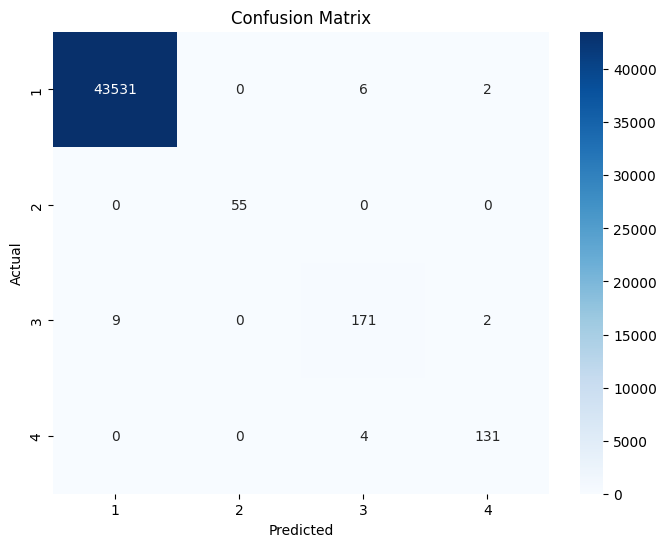

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Additional evaluation metrics

recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Recall:", recall)
print("F1 Score:", f1)

Recall: 0.9774367666550537
F1 Score: 0.9780809764188493


# ARBRE DE DECISIONS

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score,roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE



In [ ]:

# Séparer les caractéristiques (X) et la variable cible (y)
X = merged_table.drop(columns=['CLASSE_ISR'])
y = merged_table['CLASSE_ISR']

In [ ]:
# Fractionner les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


In [ ]:
# Créer un classificateur Decision Tree
classifier = DecisionTreeClassifier(criterion='entropy', max_depth=5)
# Entraîner le modèle sur les données d'entraînement
classifier.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [ ]:
# Prédire les classes sur l'ensemble de test
y_pred = classifier.predict(X_test)


In [ ]:
# Évaluer les performances du modèle
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')


In [ ]:

# Afficher la matrice de confusion
print("Confusion matrix:\n", cm)


Confusion matrix:
 [[42815   317   391    16]
 [    0    46     8     1]
 [    0     9   155    18]
 [    0     4    12   119]]


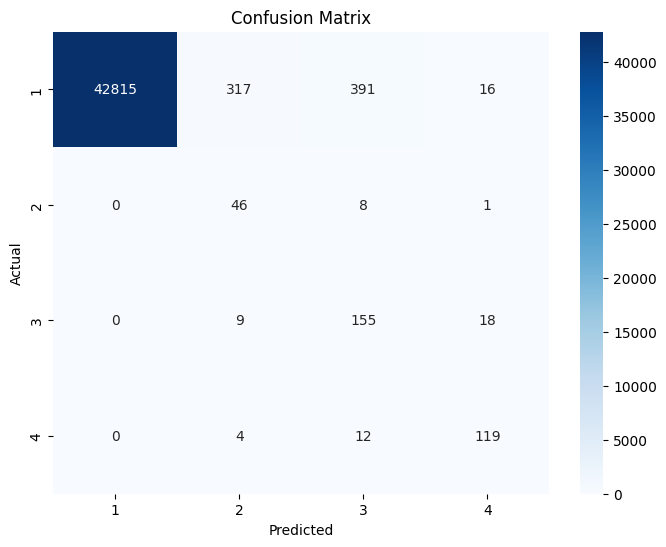

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Afficher le recall et le F1-score en pourcentage
print("Model accuracy: {:.2f}%".format(accuracy * 100))
print("Model recall: {:.2f}%".format(recall * 100))
print("Model F1 score: {:.2f}%".format(f1 * 100))


Model accuracy: 98.23%
Model recall: 88.82%
Model F1 score: 61.08%


In [ ]:
#Mapper les valeurs numériques aux labels textuels:
class_labels = {1: 'Très mauvaise D', 2: 'Mauvaise C', 3: 'Faible B', 4: 'Bonne A'}



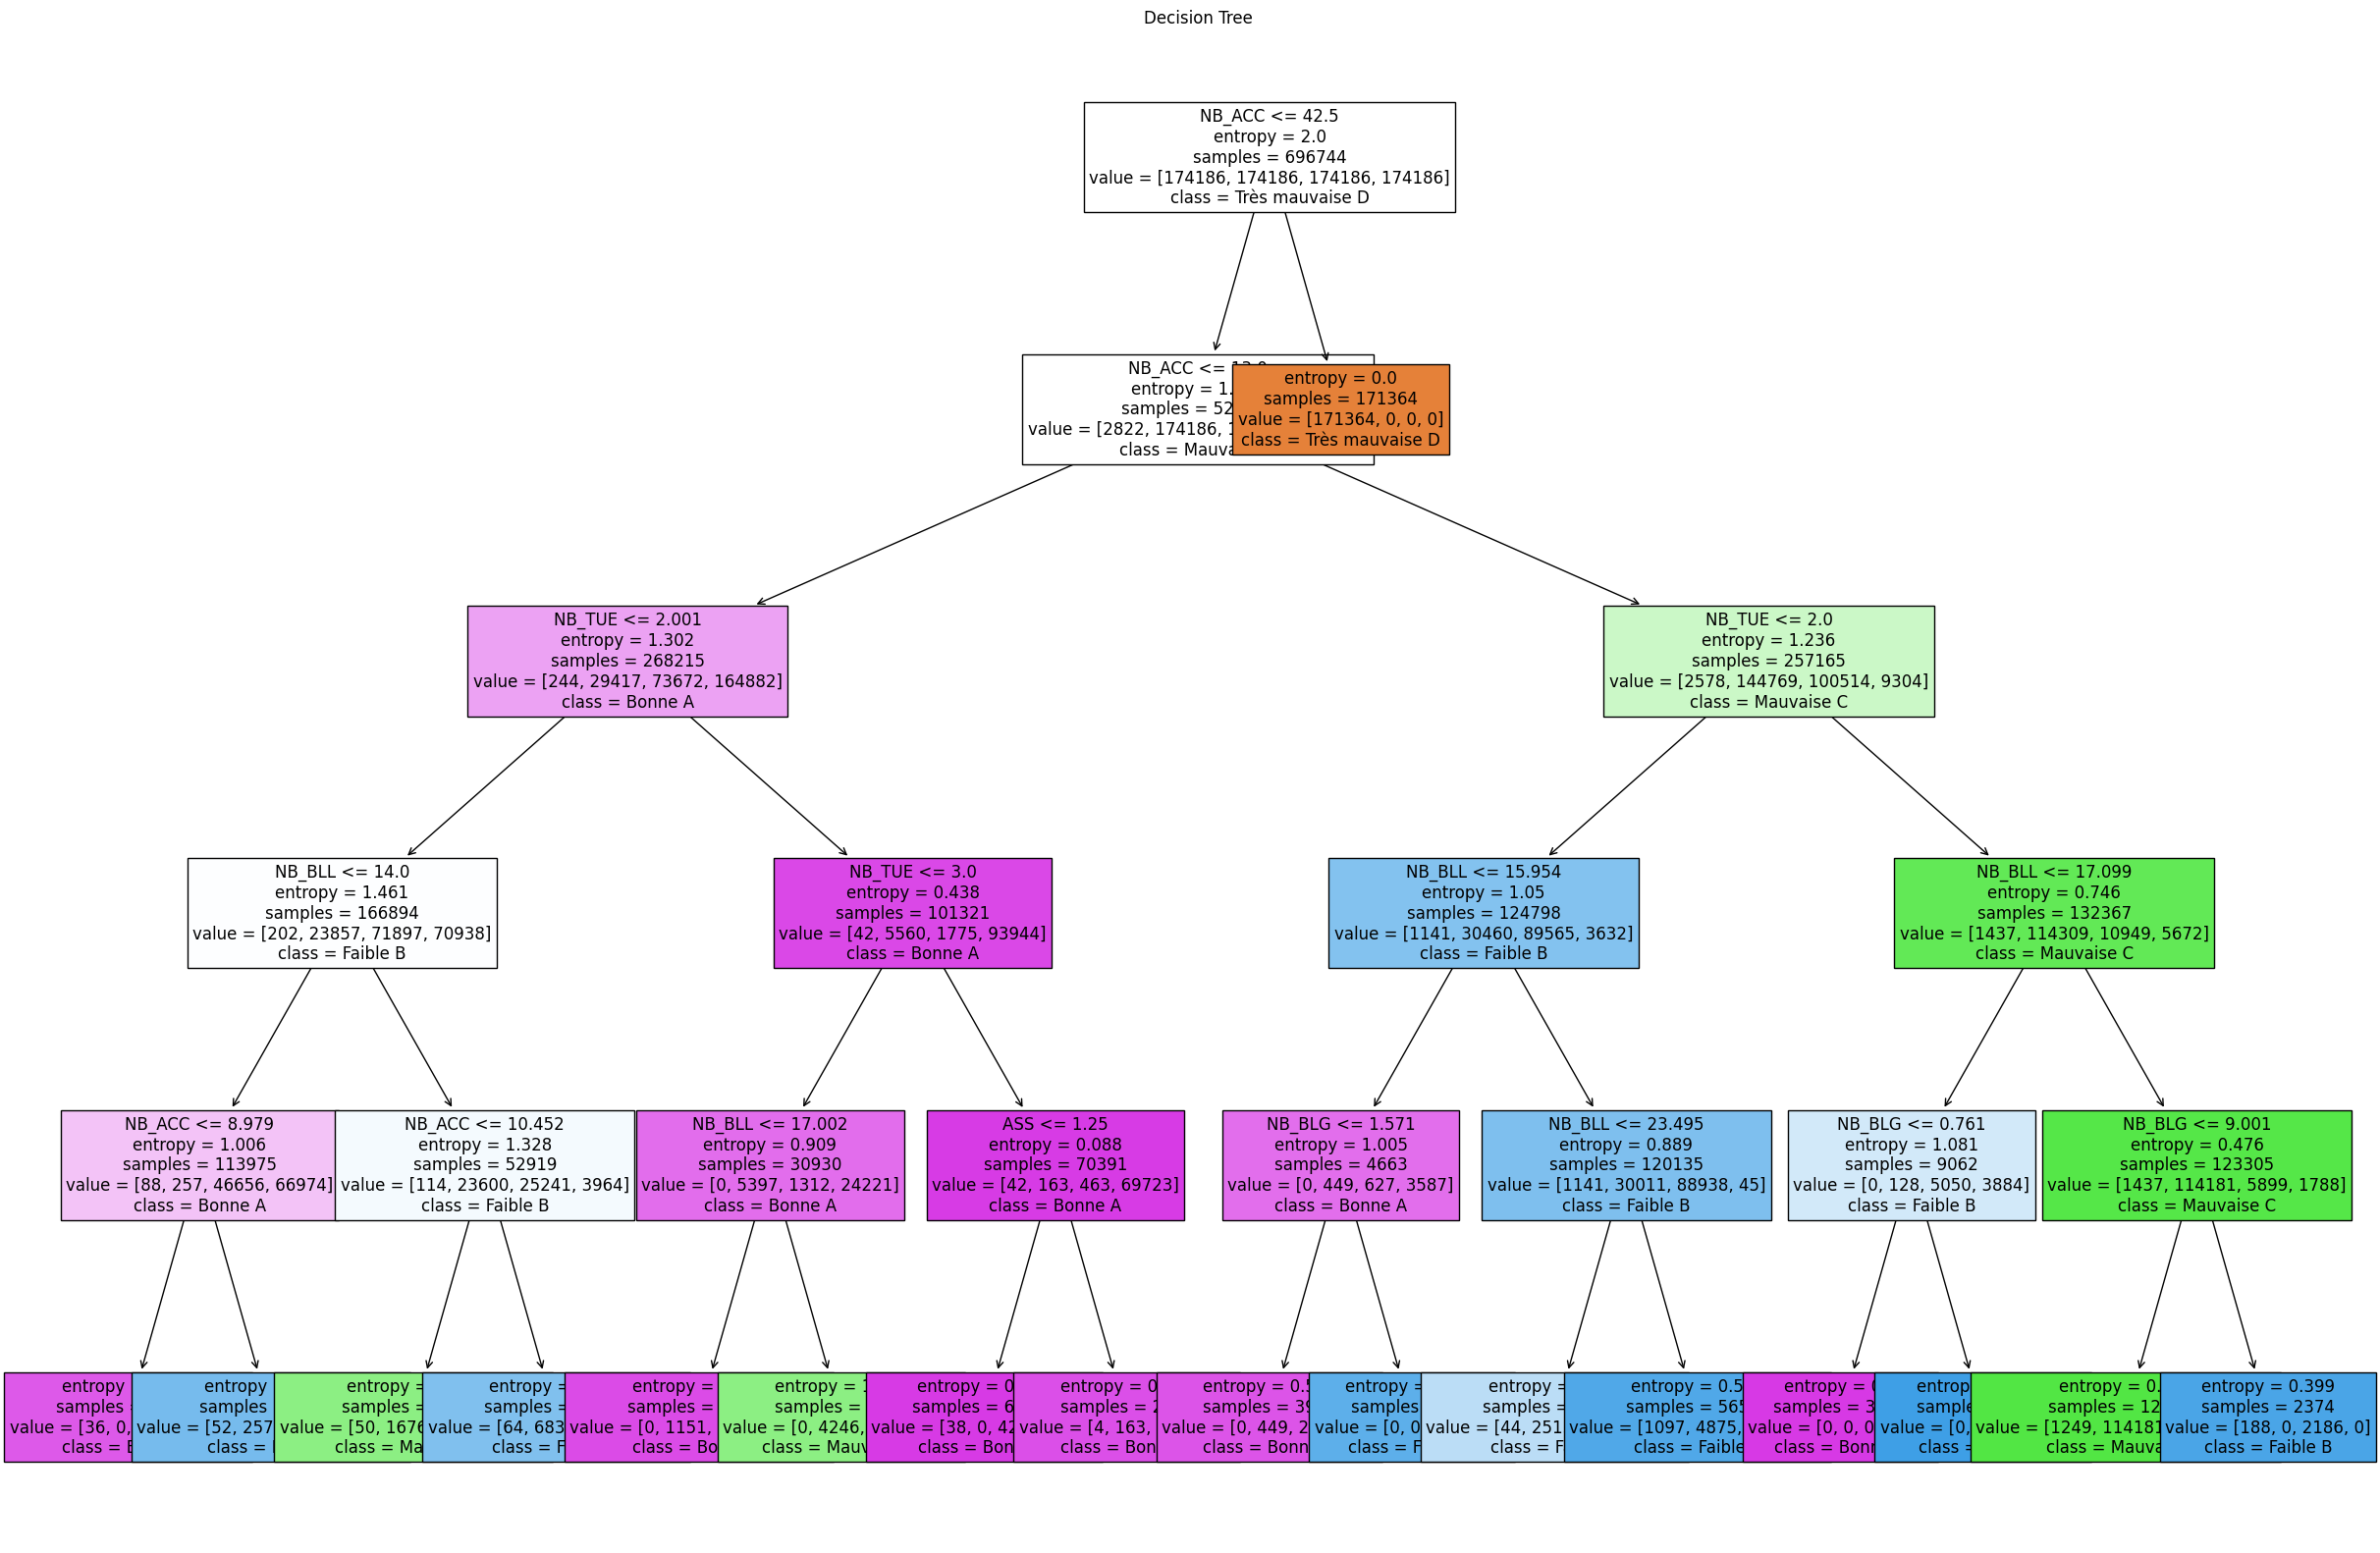

In [ ]:
# Tracer l'arbre de décision avec des étiquettes plus lisibles
plt.figure(figsize=(30, 20))  # Augmentez la taille de la figure
plot_tree(classifier,
          filled=True,
          feature_names=X.columns,
          class_names=['Très mauvaise D', 'Mauvaise C', 'Faible B', 'Bonne A'],
          fontsize=12)  # Ajustez la taille de la police
plt.title('Decision Tree')
plt.show()

# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score


In [ ]:
# Initialiser le classificateur KNN avec 30 voisins
KNN = KNeighborsClassifier(n_neighbors=30)


In [ ]:
# Entraîner le modèle KNN sur les données d'entraînement
KNN.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=30)

In [ ]:
# Faire des prédictions sur les données de test
yk_pred = KNN.predict(X_test)


In [ ]:

# Calculer la matrice de confusion
cm = confusion_matrix(y_test, yk_pred)
print("Confusion matrix:\n", cm)


Confusion matrix:
 [[41511   629   788   611]
 [    3    38     3    11]
 [    9    14   143    16]
 [   10     8     9   108]]


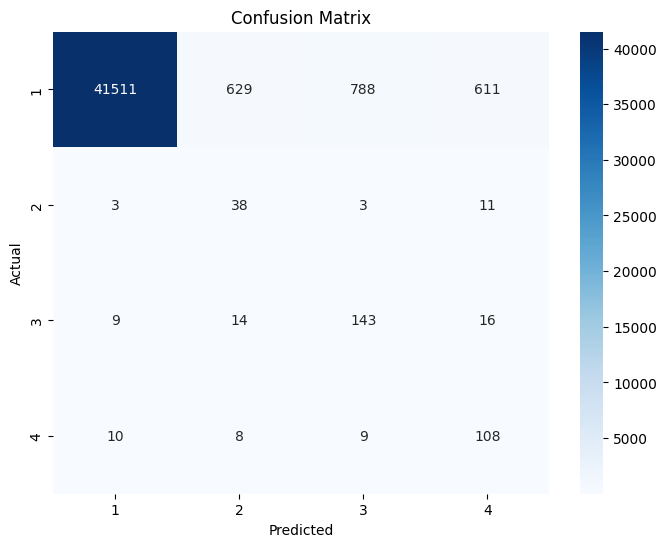

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, yk_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Calculer les métriques d'évaluation
accuracy_knn = accuracy_score(y_test, yk_pred)
recall_knn = recall_score(y_test, yk_pred, average='macro')
f1_knn = f1_score(y_test,yk_pred, average='macro')

print("Model accuracy (KNN): {:.2f}%".format(accuracy_knn * 100))
print("Model recall (KNN): {:.2f}%".format(recall_knn * 100))
print("Model F1 score (KNN): {:.2f}%".format(f1_knn * 100))

Model accuracy (KNN): 95.19%
Model recall (KNN): 80.75%
Model F1 score (KNN): 39.44%
